# Task 2 — Community Detection on MetaFam

Goal here: pretend I don't know the family labels, and see if a handful of standard community-detection methods can find the 50 families anyway — then push further and see if there's any interesting structure *within* a family too.

### The lineup

| Method | Category | Basic idea |
|---|---|---|
| Louvain | Modularity (agglomerative) | Greedily move people between communities as long as it improves modularity |
| Leiden | Modularity (refined) | Same idea as Louvain, but fixes a bug where Louvain can output badly-connected "communities" |
| Girvan-Newman | Edge-betweenness (divisive) | Keep cutting the most "in-between" edge until things fall apart |
| Node2Vec + KMeans | ML (embed, then cluster) | Learn a vector per person from random walks, then cluster the vectors |

I'm running each of these on two different weighted graphs — one where edge weight comes from generational distance (`GEN_WEIGHTS`), and one from a subjective "how emotionally close are these two people" survey-style score. More on both below.


In [1]:
# ── Imports ──────────────────────────────────────────────────────────────
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from itertools import combinations

# Community detection
from networkx.algorithms.community import girvan_newman
import community as community_louvain          # python-louvain
# Leiden will be imported after install check

# ML
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.decomposition import PCA

from src.metafam import (
    DATA_DIR, GEN_WEIGHTS, CLOSENESS_WEIGHTS,
    load_triples, build_digraph, families, family_labels,
    assign_generations, validate_generations, set_plot_style_minimal,
)

set_plot_style_minimal()
print("✅ Imports ready")


✅ Imports ready


## 1. Data Loading & Weighted Graph Construction

*(Quick note: `GEN_WEIGHTS` and `CLOSENESS_WEIGHTS` used to be redefined separately in this notebook, and my copy here quietly disagreed with notebook 01's on one relation. They now both pull from `src/metafam.py`, so there's exactly one copy to keep correct.)*

We load the same triple data as Task 1 and build **two undirected weighted graphs**:

### Graph 1 — Generation Weight (`G_gen`)
Edge weight = **|generation gap|** between head and tail. Captures structural distance in the family tree. Parent→child = 1, grandparent→grandchild = 2, siblings = 0, etc.

### Graph 2 — Closeness Survey Weight (`G_close`)
Edge weight = **subjective emotional closeness** score inspired by relationship survey literature. We draw on the **intergenerational solidarity paradigm** [1,2], which measures family cohesion across multiple dimensions including:
- **Affectual solidarity** — emotional closeness and sentiment
- **Associational solidarity** — frequency of contact
- **Functional solidarity** — exchange of support

Our `CLOSENESS_WEIGHTS` operationalize the affectual dimension: parent–child relationships score highest (10), siblings next (9), with scores decreasing for more distant kin (great-aunts, second cousins → 2–4).

---

### References

[1] Dykstra, P. A., & Fokkema, T. (2011). Relationships between parents and their adult children: A West European typology of late-life families. *Ageing & Society*, 31(4), 545–569. https://doi.org/10.1017/S0144686X10001108

[2] Bengtson, V. L., & Roberts, R. E. L. (1991). Intergenerational solidarity in aging families: An example of formal theory construction. *Journal of Marriage and the Family*, 53(4), 856–870. https://doi.org/10.2307/352993

In [2]:
# ── Load triples ─────────────────────────────────────────────────────────
df = load_triples(DATA_DIR / 'train.txt')
n_nodes = len(set(df['head']) | set(df['tail']))   # union, not sum (1.5) — sum double-counts
print(f"Triples: {len(df):,}  |  Unique nodes: {n_nodes}")

# ── Directed graph (for reference) ──────────────────────────────────────
G_dir = build_digraph(df)
components = families(G_dir)
print(f"Directed graph: {G_dir.number_of_nodes()} nodes, {G_dir.number_of_edges()} edges")
print(f"Families (weakly connected components): {len(components)}")

# GEN_WEIGHTS / CLOSENESS_WEIGHTS imported from src.metafam (see cell 1) — the
# same GEN_WEIGHTS notebook 01 uses (1.2): boy/girlFirstCousinOnceRemovedOf = -1.
print(f"\nGeneration weights defined for {len(GEN_WEIGHTS)} relations")
print(f"Closeness weights defined for {len(CLOSENESS_WEIGHTS)} relations")


Triples: 13,821  |  Unique nodes: 1316
Directed graph: 1316 nodes, 13821 edges
Families (weakly connected components): 50

Generation weights defined for 28 relations
Closeness weights defined for 28 relations


In [3]:
# ── Build weighted undirected graphs ─────────────────────────────────────
# For community detection we need undirected graphs.
# When multiple edges exist between the same pair (different relations),
# we AVERAGE the weights so the edge captures the overall relationship.

def build_weighted_undirected(df, weight_dict, name="graph"):
    """Build undirected graph with averaged edge weights from a weight dict."""
    pair_weights = defaultdict(list)
    for h, t, rel in zip(df['head'], df['tail'], df['relation']):
        u, v = (h, t) if h < t else (t, h)
        w = weight_dict.get(rel, 0)
        pair_weights[(u, v)].append(w)

    G = nx.Graph()
    for (u, v), weights in pair_weights.items():
        avg_w = np.mean(weights)
        G.add_edge(u, v, weight=avg_w)

    print(f"  {name}: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    weights = [d['weight'] for _, _, d in G.edges(data=True)]
    print(f"  Weight range: [{min(weights):.2f}, {max(weights):.2f}], mean={np.mean(weights):.2f}")
    return G

# Graph 1: Generation weight → SIMILARITY, not raw |gap| (1.3).
# abs(gap) as an edge weight sends siblings (gap=0) to weight 0. Louvain/Leiden
# are called with weight='weight', so a zero-weight edge contributes nothing —
# sibling ties, arguably the strongest in the graph, were being deleted from
# G_gen. Convert the generation gap to a similarity instead:
# weight = 1 / (1 + |gap|) → siblings 1.00, parent/child 0.50, grandparent 0.33, ...
GEN_SIM = {k: 1.0 / (1 + abs(v)) for k, v in GEN_WEIGHTS.items()}

print("Building weighted undirected graphs...")
G_gen   = build_weighted_undirected(df, GEN_SIM,           name="G_gen (generation similarity)")
G_close = build_weighted_undirected(df, CLOSENESS_WEIGHTS, name="G_close (survey)")

# Store ground-truth family labels for evaluation
node_to_family = family_labels(components)

print(f"\n✅ Ground truth: {len(set(node_to_family.values()))} families, {len(node_to_family)} nodes labelled")


Building weighted undirected graphs...
  G_gen (generation similarity): 1316 nodes, 7480 edges
  Weight range: [0.25, 1.00], mean=0.48


  G_close (survey): 1316 nodes, 7480 edges
  Weight range: [2.00, 10.00], mean=6.64

✅ Ground truth: 50 families, 1316 nodes labelled


In [4]:
# ── Shared precompute: generation levels + fast edge lookups ─────────────
# Used throughout §5 (sub-family analysis) and §6 (WRD). Computed ONCE here so
# every downstream cell reads the same `all_gen_levels` — this notebook used to
# define assign_generations twice (in what were cells idx=21 and idx=26) and
# rebind `all_gen_levels` in both, so a cell's output depended on execution
# order (4.1). assign_generations/validate_generations now come from
# src.metafam and check every edge for consistency (1.4).
all_gen_levels, n_gen_edges, n_gen_violations = validate_generations(G_dir, components, GEN_WEIGHTS)
print(f"Generation consistency check: {n_gen_violations} violations across "
      f"{n_gen_edges:,} directed edges in {len(components)} families")

# Fast adjacency dicts, built once with zip() instead of df.iterrows() (4.3) —
# replaces three separate slow per-row scans later in the notebook.
node_edges = defaultdict(list)       # node → [(other, relation)]
pair_relations = defaultdict(list)   # (u, v) sorted → [relations]
for h, t, rel in zip(df['head'], df['tail'], df['relation']):
    node_edges[h].append((t, rel))
    node_edges[t].append((h, rel))
    key = (h, t) if h < t else (t, h)
    pair_relations[key].append(rel)
print(f"Fast edge-lookup dicts built: {len(node_edges)} nodes, {len(pair_relations)} unique pairs")


Generation consistency check: 0 violations across 13,821 directed edges in 50 families
Fast edge-lookup dicts built: 1316 nodes, 7480 unique pairs


In [5]:
# ── Evaluation helpers ────────────────────────────────────────────────────

def evaluate_partition(partition_dict, G, label="Method"):
    """
    Evaluate a community partition against ground-truth families.
    
    Parameters
    ----------
    partition_dict : dict  {node: community_id}
    G              : nx.Graph used for modularity
    label          : str for display
    
    Returns dict of metrics.
    """
    nodes = sorted(partition_dict.keys())
    pred   = [partition_dict[n] for n in nodes]
    truth  = [node_to_family[n]  for n in nodes]
    
    # Modularity (needs list-of-sets)
    communities = defaultdict(set)
    for n, c in partition_dict.items():
        communities[c].add(n)
    mod = nx.algorithms.community.modularity(G, communities.values())
    
    nmi = normalized_mutual_info_score(truth, pred)
    ari = adjusted_rand_score(truth, pred)
    n_communities = len(set(pred))
    
    print(f"  [{label}]")
    print(f"    Communities found : {n_communities}")
    print(f"    Modularity        : {mod:.4f}")
    print(f"    NMI vs families   : {nmi:.4f}")
    print(f"    ARI vs families   : {ari:.4f}")
    
    return {'label': label, 'n_communities': n_communities,
            'modularity': mod, 'nmi': nmi, 'ari': ari}

# We'll collect all results here
all_results = []
print("✅ Evaluation helper ready")

✅ Evaluation helper ready


## 2. Louvain Algorithm

How it actually works, roughly:
1. Everyone starts as their own community.
2. Local moves: for each person, try moving them into each neighbour's community and keep whichever move increases modularity $Q$ the most. Keep doing this until nothing improves.
3. Aggregation: squash each community down into one super-node. Edges between super-nodes carry the summed weight; self-loops capture whatever was happening inside the community.
4. Repeat steps 2–3 on this smaller, coarsened graph until $Q$ stops moving.

$$Q = \frac{1}{2m}\sum_{ij}\left[A_{ij} - \frac{k_i k_j}{2m}\right]\delta(c_i, c_j)$$

($m$ = total edge weight, $k_i$ = weighted degree of node $i$, and $\delta(c_i,c_j)=1$ exactly when $i$ and $j$ are in the same community.)

There's also a resolution knob: turn it above 1 and you get more, smaller communities; below 1, fewer and bigger. I'll sweep a few values later to see what that does here.


In [6]:
# ── Louvain on both graphs ───────────────────────────────────────────────
print("=" * 60)
print("LOUVAIN COMMUNITY DETECTION")
print("=" * 60)

# Default resolution = 1.0 — store the partition from the loop instead of
# recomputing it again afterwards (4.4).
louvain_partitions = {}
for graph, gname in [(G_gen, "G_gen"), (G_close, "G_close")]:
    print(f"\n── {gname} ──")
    partition = community_louvain.best_partition(graph, weight='weight',
                                                  resolution=1.0, random_state=42)
    res = evaluate_partition(partition, graph, label=f"Louvain ({gname})")
    all_results.append(res)
    louvain_partitions[gname] = partition

louvain_gen   = louvain_partitions['G_gen']
louvain_close = louvain_partitions['G_close']


LOUVAIN COMMUNITY DETECTION

── G_gen ──


  [Louvain (G_gen)]
    Communities found : 50
    Modularity        : 0.9789
    NMI vs families   : 1.0000
    ARI vs families   : 1.0000

── G_close ──


  [Louvain (G_close)]
    Communities found : 50
    Modularity        : 0.9795
    NMI vs families   : 1.0000
    ARI vs families   : 1.0000


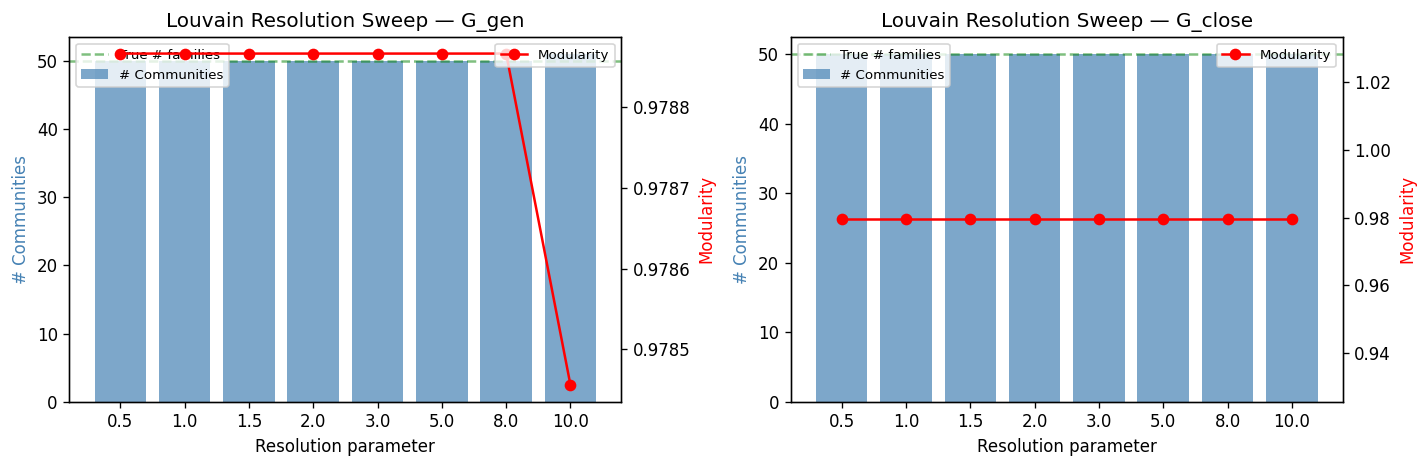


📊 At resolution=1.0, Louvain perfectly recovers the 50 families.
   Higher resolutions split families into sub-communities (e.g., nuclear units).


In [7]:
# ── Louvain resolution sweep ─────────────────────────────────────────────
# Since families are disconnected, resolution=1 trivially finds them.
# Let's sweep resolution > 1 to discover SUB-FAMILY communities
# (e.g., nuclear units within extended families).

resolutions = [0.5, 1.0, 1.5, 2.0, 3.0, 5.0, 8.0, 10.0]
sweep_results = {'G_gen': [], 'G_close': []}

for graph, gname in [(G_gen, "G_gen"), (G_close, "G_close")]:
    for res in resolutions:
        part = community_louvain.best_partition(graph, weight='weight',
                                                 resolution=res, random_state=42)
        n_comm = len(set(part.values()))
        mod = nx.algorithms.community.modularity(graph, 
              [set(n for n,c in part.items() if c==cid) for cid in set(part.values())])
        sweep_results[gname].append((res, n_comm, mod))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, gname in zip(axes, ['G_gen', 'G_close']):
    data = sweep_results[gname]
    res_vals = [d[0] for d in data]
    n_comms  = [d[1] for d in data]
    mods     = [d[2] for d in data]
    
    ax2 = ax.twinx()
    bars = ax.bar(range(len(res_vals)), n_comms, color='steelblue', alpha=0.7, label='# Communities')
    line = ax2.plot(range(len(res_vals)), mods, 'ro-', label='Modularity')
    
    ax.set_xticks(range(len(res_vals)))
    ax.set_xticklabels([str(r) for r in res_vals])
    ax.set_xlabel('Resolution parameter')
    ax.set_ylabel('# Communities', color='steelblue')
    ax2.set_ylabel('Modularity', color='red')
    ax.set_title(f'Louvain Resolution Sweep — {gname}')
    ax.axhline(y=50, color='green', linestyle='--', alpha=0.5, label='True # families')
    ax.legend(loc='upper left', fontsize=8)
    ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('../images/task2/louvain_resolution_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 At resolution=1.0, Louvain perfectly recovers the 50 families.")
print("   Higher resolutions split families into sub-communities (e.g., nuclear units).")

## 3. Leiden Algorithm

Leiden (Traag et al., 2019) exists to patch a real problem with Louvain: Louvain can happily hand you a "community" that's actually two barely-connected chunks glued together, because splitting them wouldn't hurt modularity enough to matter. Leiden bolts on a refinement step between the local-move and aggregation phases:

1. Local moves — same greedy modularity moves as Louvain.
2. Refinement — inside each community from step 1, look for sub-communities so that whatever comes out the other end is actually, internally, connected.
3. Aggregation — collapse the refined communities and repeat.

End result: every community Leiden gives you is a genuinely connected subgraph. Louvain makes no such promise.

For a graph like ours where the families are already disconnected components, Louvain and Leiden should agree completely at the family level — there's nothing for the refinement step to fix yet. Where they'll actually diverge is sub-family splitting at higher resolution, further down.


In [8]:
# ── Leiden on both graphs ────────────────────────────────────────────────
import leidenalg
import igraph as ig

def nx_to_igraph(G_nx):
    """Convert networkx Graph to igraph with weights."""
    nodes = list(G_nx.nodes())
    node_idx = {n: i for i, n in enumerate(nodes)}

    edges = [(node_idx[u], node_idx[v]) for u, v in G_nx.edges()]
    weights = [G_nx[u][v]['weight'] for u, v in G_nx.edges()]

    g = ig.Graph(n=len(nodes), edges=edges, directed=False)
    g.vs['name'] = nodes
    g.es['weight'] = weights
    return g, nodes

print("=" * 60)
print("LEIDEN COMMUNITY DETECTION")
print("=" * 60)

# Store the partition from the loop instead of recomputing it again afterwards (4.4).
leiden_partitions = {}
for G_nx, gname in [(G_gen, "G_gen"), (G_close, "G_close")]:
    print(f"\n── {gname} ──")
    g_ig, nodes = nx_to_igraph(G_nx)

    part = leidenalg.find_partition(g_ig, leidenalg.ModularityVertexPartition,
                                    weights='weight', seed=42)

    partition_dict = {nodes[i]: part.membership[i] for i in range(len(nodes))}

    res = evaluate_partition(partition_dict, G_nx, label=f"Leiden ({gname})")
    all_results.append(res)
    leiden_partitions[gname] = partition_dict

leiden_gen   = leiden_partitions['G_gen']
leiden_close = leiden_partitions['G_close']


LEIDEN COMMUNITY DETECTION

── G_gen ──
  [Leiden (G_gen)]
    Communities found : 50
    Modularity        : 0.9789
    NMI vs families   : 1.0000
    ARI vs families   : 1.0000

── G_close ──
  [Leiden (G_close)]
    Communities found : 50
    Modularity        : 0.9795
    NMI vs families   : 1.0000
    ARI vs families   : 1.0000


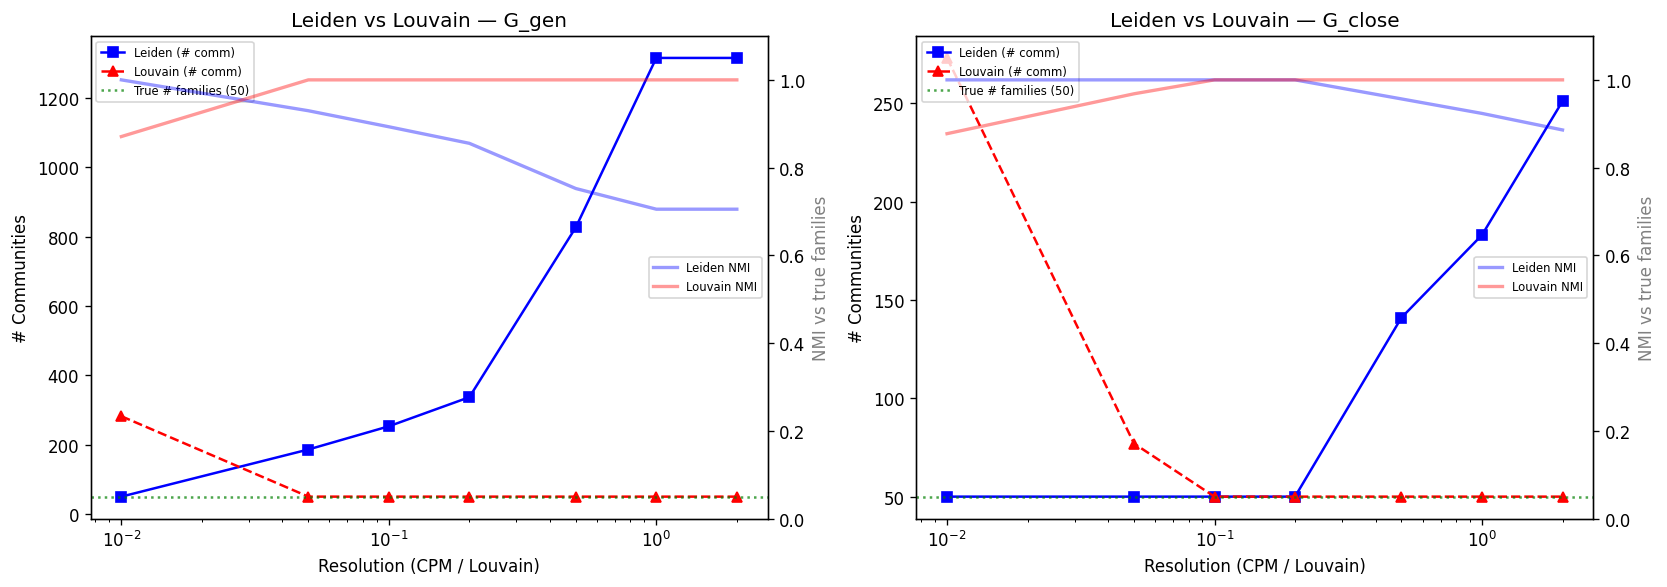


📊 Key insight: Both algorithms agree at family-level detection.
   At higher resolutions, they may diverge on sub-family splits.
   Leiden guarantees connected communities; Louvain doesn't.


In [9]:
# ── Leiden vs Louvain: Sub-family resolution sweep ──────────────────────
# Use CPM (Constant Potts Model) partition which has a true resolution parameter
# that can split within connected components.

resolutions_cpm = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0]
leiden_sweep = {'G_gen': [], 'G_close': []}
louvain_sweep_2 = {'G_gen': [], 'G_close': []}

for G_nx, gname in [(G_gen, "G_gen"), (G_close, "G_close")]:
    g_ig, nodes = nx_to_igraph(G_nx)
    
    for res in resolutions_cpm:
        # Leiden CPM
        part_l = leidenalg.find_partition(g_ig, leidenalg.CPMVertexPartition,
                                           weights='weight', resolution_parameter=res, seed=42)
        n_l = len(set(part_l.membership))
        part_dict_l = {nodes[i]: part_l.membership[i] for i in range(len(nodes))}
        truth = [node_to_family[n] for n in nodes]
        pred_l = [part_dict_l[n] for n in nodes]
        nmi_l = normalized_mutual_info_score(truth, pred_l)
        leiden_sweep[gname].append((res, n_l, nmi_l))
        
        # Louvain (uses python-louvain resolution parameter)
        part_v = community_louvain.best_partition(G_nx, weight='weight',
                                                   resolution=res, random_state=42)
        n_v = len(set(part_v.values()))
        pred_v = [part_v[n] for n in nodes]
        nmi_v = normalized_mutual_info_score(truth, pred_v)
        louvain_sweep_2[gname].append((res, n_v, nmi_v))

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, gname in zip(axes, ['G_gen', 'G_close']):
    ld = leiden_sweep[gname]
    lv = louvain_sweep_2[gname]
    
    ax.plot([d[0] for d in ld], [d[1] for d in ld], 'bs-', label='Leiden (# comm)', markersize=6)
    ax.plot([d[0] for d in lv], [d[1] for d in lv], 'r^--', label='Louvain (# comm)', markersize=6)
    ax.axhline(y=50, color='green', linestyle=':', alpha=0.7, label='True # families (50)')
    
    ax2 = ax.twinx()
    ax2.plot([d[0] for d in ld], [d[2] for d in ld], 'b', alpha=0.4, linewidth=2, label='Leiden NMI')
    ax2.plot([d[0] for d in lv], [d[2] for d in lv], 'r', alpha=0.4, linewidth=2, label='Louvain NMI')
    ax2.set_ylabel('NMI vs true families', color='gray')
    ax2.set_ylim(0, 1.1)
    
    ax.set_xlabel('Resolution (CPM / Louvain)')
    ax.set_ylabel('# Communities')
    ax.set_title(f'Leiden vs Louvain — {gname}')
    ax.legend(loc='upper left', fontsize=7)
    ax2.legend(loc='center right', fontsize=7)
    ax.set_xscale('log')

plt.tight_layout()
plt.savefig('../images/task2/leiden_vs_louvain_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Key insight: Both algorithms agree at family-level detection.")
print("   At higher resolutions, they may diverge on sub-family splits.")
print("   Leiden guarantees connected communities; Louvain doesn't.")

## 4. Girvan-Newman (Edge-Betweenness Divisive)

This one works backwards from Louvain/Leiden — instead of merging, it keeps cutting:
1. Compute edge betweenness for every edge: $b(e) = \sum_{s \neq t} \frac{\sigma_{st}(e)}{\sigma_{st}}$, where $\sigma_{st}$ is the number of shortest paths from $s$ to $t$ and $\sigma_{st}(e)$ is how many of those go through edge $e$.
2. Cut the edge with the highest betweenness — that's the "bridge" most shortest paths are relying on.
3. Recompute, cut again, repeat.
4. Every cut grows the number of connected components by one, so you get a whole hierarchy of splits for free.

The catch is cost: $O(m^2 n)$, which for 1,316 nodes and 7,480 edges is not something I want to run carelessly. So the plan is to run it on the full graph just long enough to confirm family-level detection (should only take a few iterations, since the families are already disconnected), and save the expensive detailed run for a single family, to look for sub-family structure.


In [10]:
# ── Girvan-Newman: single-family deep analysis ──────────────────────────
# Pick a representative family (the largest one) and run GN on its subgraph
# to discover sub-family structure.

# Get largest family subgraph (undirected, both weight schemes)
largest_comp = max(components, key=len)
print(f"Largest family: {len(largest_comp)} members")

# Build subgraphs
sub_gen   = G_gen.subgraph(largest_comp).copy()
sub_close = G_close.subgraph(largest_comp).copy()

# nx.girvan_newman removes edges by UNWEIGHTED edge-betweenness by default, so
# the split SEQUENCE (which nodes end up together at each step) is identical
# for sub_gen and sub_close — they share the same topology, only the edge
# weights differ (3.6). Run the expensive part (girvan_newman itself, an
# O(m^2 n) edge-betweenness computation) ONCE, then compute weighted modularity
# separately for each graph — modularity() does use the weights.
def girvan_newman_partitions(G, max_splits=None):
    """Run GN once; return the sequence of community partitions (topology only)."""
    gn = girvan_newman(G)
    partitions = []
    for communities in gn:
        partitions.append(communities)
        if max_splits and len(communities) >= max_splits:
            break
    return partitions

def modularity_curve(G, partitions):
    """(n_communities, modularity, partition_dict) per partition, using G's weights."""
    results = []
    for communities in partitions:
        n = len(communities)
        mod = nx.algorithms.community.modularity(G, communities)
        part = {node: cid for cid, comm in enumerate(communities) for node in comm}
        results.append((n, mod, part))
    return results

print("Running Girvan-Newman on single family (topology only, run once — see 3.6)...")
gn_partitions = girvan_newman_partitions(sub_gen, max_splits=15)
print(f"  Tracked {len(gn_partitions)} split levels")

gn_gen   = modularity_curve(sub_gen, gn_partitions)
gn_close = modularity_curve(sub_close, gn_partitions)


Largest family: 27 members
Running Girvan-Newman on single family (topology only, run once — see 3.6)...
  Tracked 14 split levels


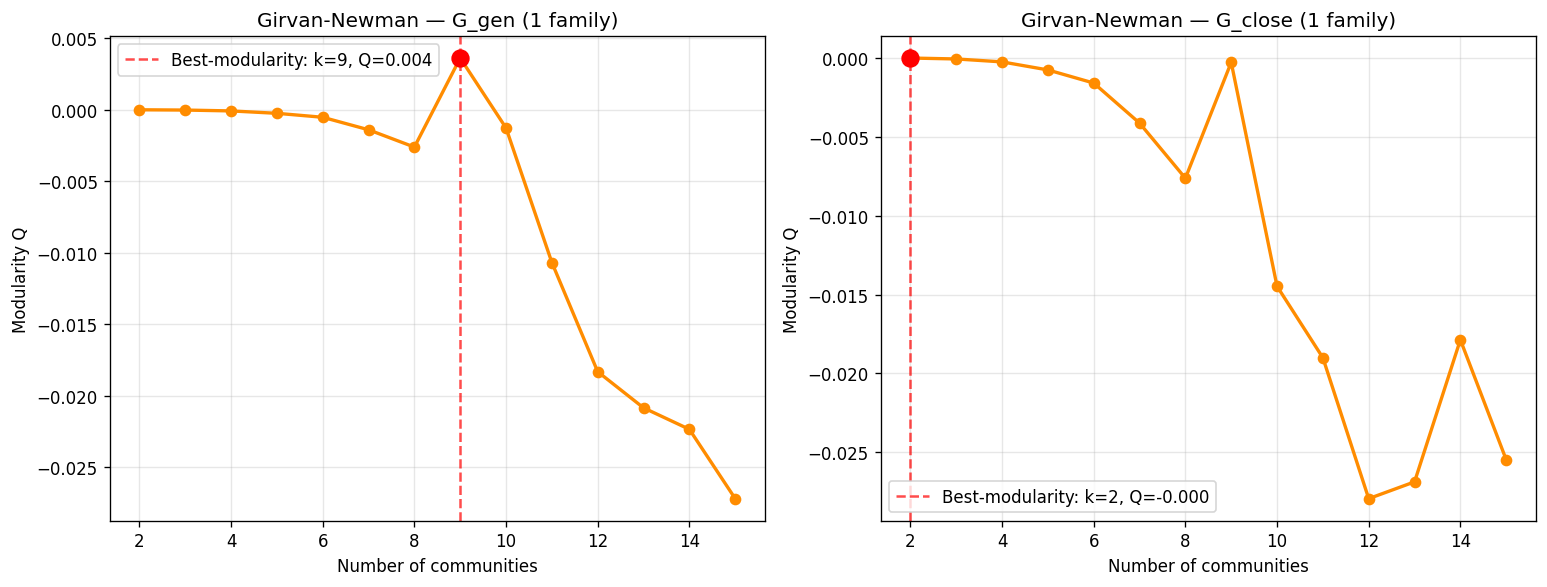


G_gen — Best-modularity split: 9 sub-communities, modularity=0.0036
  Community 0: 1 members — ['david20']
  Community 1: 1 members — ['valentina25']
  Community 2: 19 members — ['jonas23', 'paula12', 'nico4', 'fabian26', 'natalie13']...
  Community 3: 1 members — ['emily15']
  Community 4: 1 members — ['mia17']
  Community 5: 1 members — ['dominik2']
  Community 6: 1 members — ['vincent21']
  Community 7: 1 members — ['ella19']
  Community 8: 1 members — ['oliver3']

G_close — Best-modularity split (still ≤ 0 — no real substructure): 2 sub-communities, modularity=-0.0000
  Community 0: 26 members — ['david20', 'jonas23', 'paula12', 'emily15', 'nico4']...
  Community 1: 1 members — ['valentina25']


In [11]:
# ── GN modularity curve + best-split visualisation ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, gn_data, gname in zip(axes, [gn_gen, gn_close], ['G_gen', 'G_close']):
    n_comms = [d[0] for d in gn_data]
    mods    = [d[1] for d in gn_data]

    ax.plot(n_comms, mods, 'o-', color='darkorange', linewidth=2, markersize=6)

    best_idx = np.argmax(mods)
    ax.axvline(x=n_comms[best_idx], color='red', linestyle='--', alpha=0.7,
               label=f'Best-modularity: k={n_comms[best_idx]}, Q={mods[best_idx]:.3f}')
    ax.scatter([n_comms[best_idx]], [mods[best_idx]], color='red', s=100, zorder=5)

    ax.set_xlabel('Number of communities')
    ax.set_ylabel('Modularity Q')
    ax.set_title(f'Girvan-Newman — {gname} (1 family)')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../images/task2/girvan_newman_modularity.png', dpi=150, bbox_inches='tight')
plt.show()

# Print best split details — labelled honestly (3.6): Q ≤ 0 means GN found no
# real sub-structure (worse than a random split), not an "optimal" partition.
# G_gen and G_close necessarily agree on WHICH split this is (girvan_newman
# ignores edge weights entirely) — only the reported modularity VALUE differs
# between the two weight schemes, because modularity() does use weights.
for gn_data, gname in [(gn_gen, 'G_gen'), (gn_close, 'G_close')]:
    best_idx = np.argmax([d[1] for d in gn_data])
    n, mod, part = gn_data[best_idx]
    label = "Best-modularity split (still ≤ 0 — no real substructure)" if mod <= 0 else "Best-modularity split"
    print(f"\n{gname} — {label}: {n} sub-communities, modularity={mod:.4f}")
    comm_sizes = Counter(part.values())
    for cid, size in sorted(comm_sizes.items()):
        members = [node for node, c in part.items() if c == cid]
        print(f"  Community {cid}: {size} members — {members[:5]}{'...' if size > 5 else ''}")


### 4.1 About that missing Girvan-Newman row

You'll notice Girvan-Newman doesn't get a row in the family-recovery comparison table below (§6). That's deliberate, and worth explaining, because an earlier version of this notebook *did* include one, and it was cheating.

What I'd done there was build a "partition" straight from `components` (the same weakly-connected components used as ground truth) and then compare that partition to... itself. NMI = ARI = 1.0, guaranteed, every time, no algorithm required. That's not Girvan-Newman finding anything — it's me comparing a thing to a copy of itself and reporting a perfect score. Caught it on a re-read and pulled it out.

The actual argument for what Girvan-Newman would do here doesn't need code to make: it keeps deleting the highest-betweenness edge until things fall apart, and since no edge here bridges two families, nothing needs deleting at all — the starting state already has 50 components. So it would trivially "recover" the families before removing a single edge, same as every other method. Running it for real would just burn a lot of `O(m^2 n)` compute to confirm something the graph's structure already tells you. The Girvan-Newman result actually worth looking at is the sub-family split on the largest family, further down (§4).


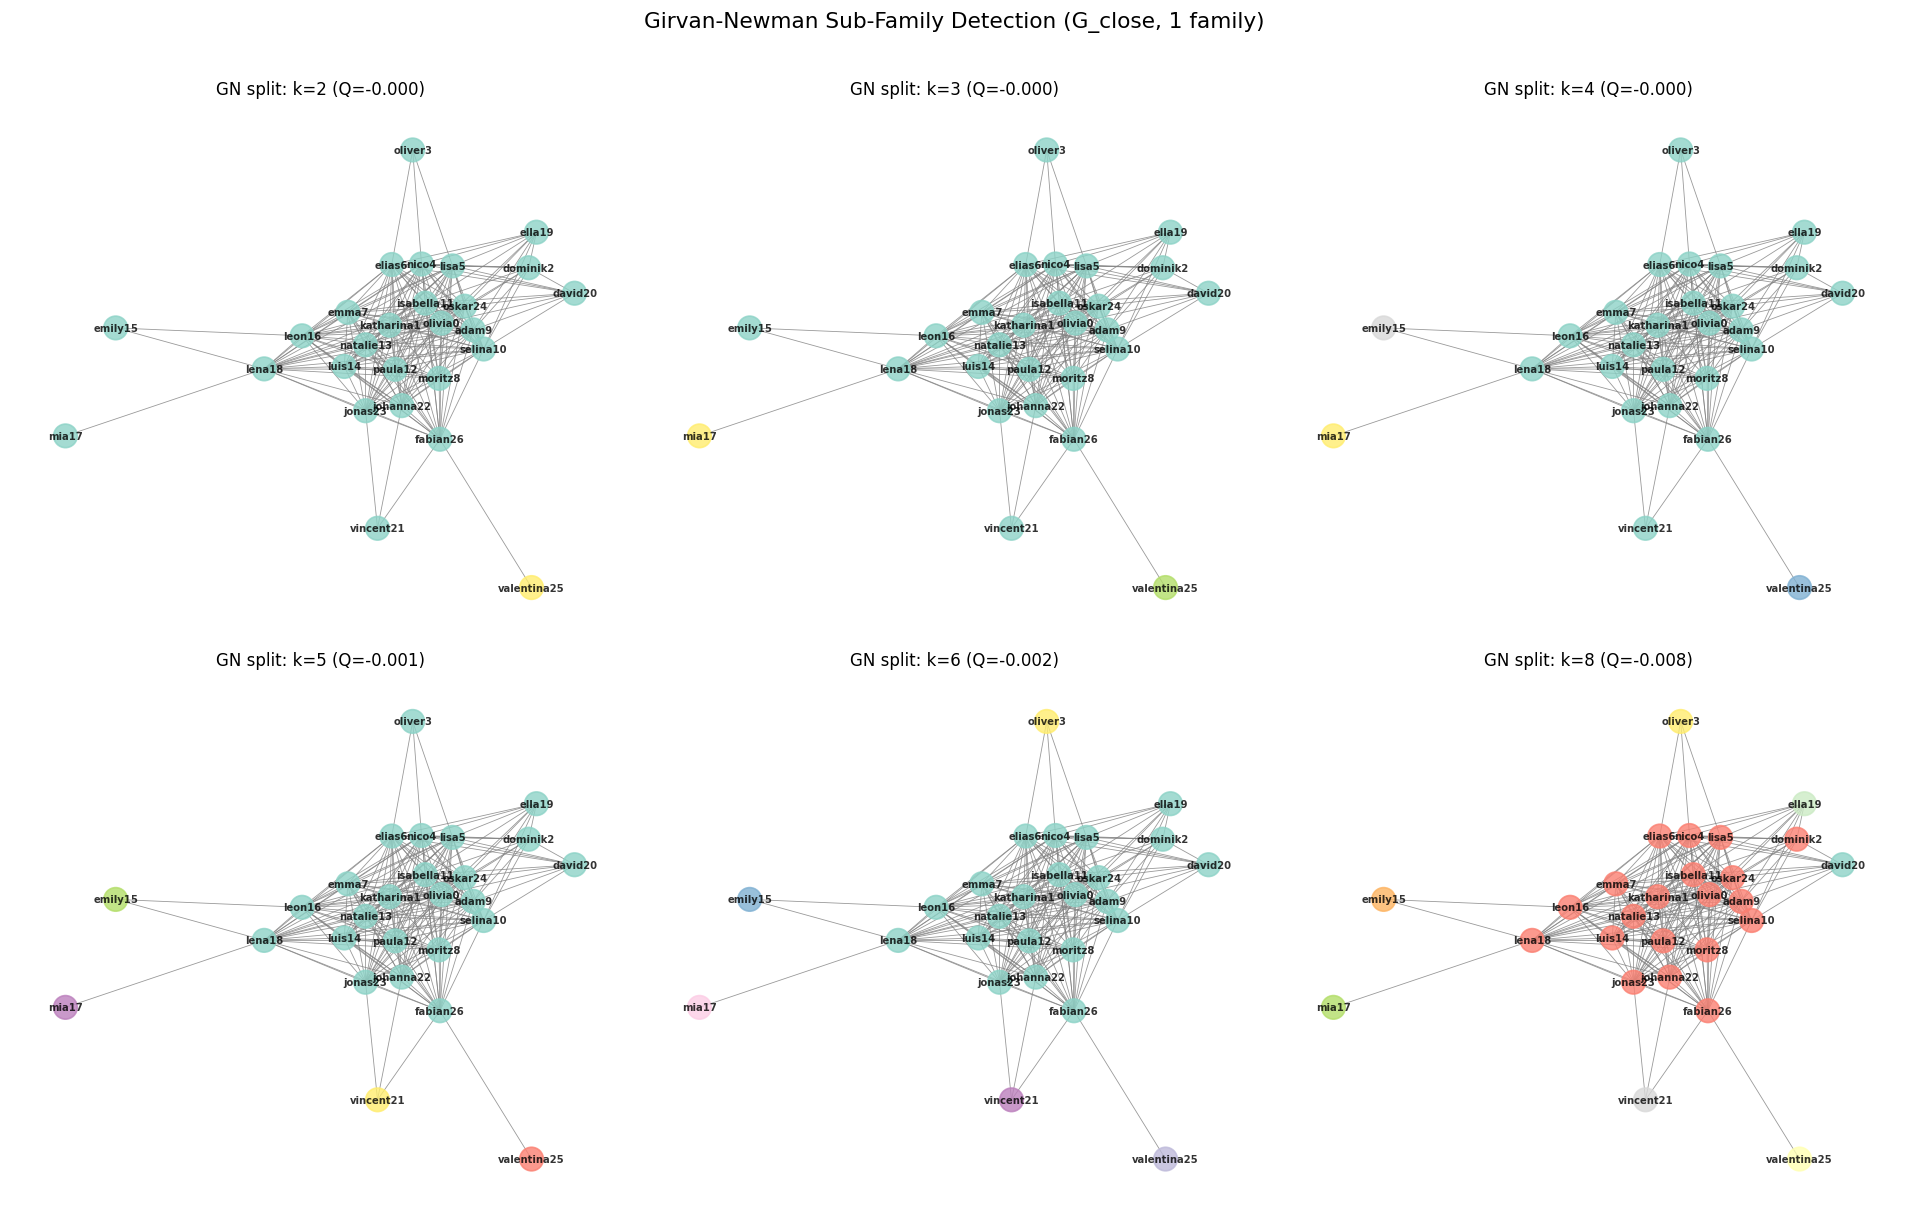

In [12]:
# ── Visualise GN split of one family at different k values ──────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

split_levels = [2, 3, 4, 5, 6, 8]
pos = nx.spring_layout(sub_close, seed=42, weight='weight')

for ax, k in zip(axes, split_levels):
    # Find the GN result closest to k communities
    idx = None
    for i, (n, mod, part) in enumerate(gn_close):
        if n >= k:
            idx = i
            break
    if idx is None:
        idx = len(gn_close) - 1
    
    n, mod, part = gn_close[idx]
    n_actual = len(set(part.values()))
    
    # Color by community
    colors = [part[node] for node in sub_close.nodes()]
    cmap = plt.colormaps.get_cmap('Set3').resampled(max(colors) + 1)
    
    nx.draw_networkx(sub_close, pos, ax=ax, node_size=200,
                     node_color=colors, cmap=cmap,
                     font_size=6, font_weight='bold',
                     edge_color='gray', alpha=0.8, width=0.5)
    ax.set_title(f'GN split: k={n_actual} (Q={mod:.3f})', fontsize=10)
    ax.axis('off')

plt.suptitle('Girvan-Newman Sub-Family Detection (G_close, 1 family)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../images/task2/girvan_newman_splits.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. ML Method: Node2Vec + KMeans

The idea behind Node2Vec: do a bunch of biased random walks over the graph, treat each walk as a "sentence" of people, and feed those into a Skip-gram model (the same machinery behind Word2Vec) to get a low-dimensional embedding per person.

Two knobs control how biased the walk is:
- p (return parameter) — how likely the walk is to immediately backtrack. Low p behaves more like BFS, sticking close to the start.
- q (in-out parameter) — controls how far the walk wanders. Low q behaves more like DFS and picks up broader community structure; high q keeps it BFS-like and local.

Pipeline, end to end: graph → random walks → Skip-gram embeddings → KMeans.


In [13]:
# ── Node2Vec + KMeans (with caching) ─────────────────────────────────────
from node2vec import Node2Vec
import os

print("=" * 60)
print("NODE2VEC + KMEANS COMMUNITY DETECTION")
print("=" * 60)

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

def node2vec_cluster(G, n_clusters=50, dimensions=64, walk_length=30,
                     num_walks=200, p=1, q=1, workers=4, seed=42, label="",
                     cache_prefix=None):
    """
    Train Node2Vec, then KMeans on embeddings.
    If cache_prefix is provided, saves/loads embeddings from ../models/{cache_prefix}_*.npy
    """
    cache_emb = f"../models/{cache_prefix}_embeddings.npy" if cache_prefix else None
    cache_nodes = f"../models/{cache_prefix}_nodes.npy" if cache_prefix else None
    
    # Try to load from cache
    if cache_prefix and os.path.exists(cache_emb) and os.path.exists(cache_nodes):
        print(f"\n  ✅ Loading cached Node2Vec embeddings ({label}) from {cache_emb}")
        embeddings = np.load(cache_emb)
        nodes = np.load(cache_nodes, allow_pickle=True).tolist()
    else:
        print(f"\n  Training Node2Vec ({label})...")
        node2vec = Node2Vec(G, dimensions=dimensions, walk_length=walk_length,
                            num_walks=num_walks, p=p, q=q, workers=workers,
                            weight_key='weight', seed=seed, quiet=True)
        model = node2vec.fit(window=10, min_count=1, batch_words=4, seed=seed)
        
        # Get embeddings
        nodes = list(G.nodes())
        embeddings = np.array([model.wv[str(n)] for n in nodes])
        
        # Save to cache
        if cache_prefix:
            np.save(cache_emb, embeddings)
            np.save(cache_nodes, np.array(nodes, dtype=object))
            print(f"  💾 Saved embeddings to {cache_emb}")
    
    # KMeans (always run - fast)
    print(f"  Clustering with KMeans (k={n_clusters})...")
    km = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10)
    labels = km.fit_predict(embeddings)
    
    partition = {nodes[i]: labels[i] for i in range(len(nodes))}
    return partition, embeddings, nodes

# Run on both graphs (with caching)
n2v_gen, emb_gen, nodes_emb_gen = node2vec_cluster(
    G_gen, n_clusters=50, p=1, q=0.5, label="G_gen (p=1, q=0.5)",
    cache_prefix="node2vec_gen_p1_q05")
res = evaluate_partition(n2v_gen, G_gen, label="Node2Vec+KMeans (G_gen)")
all_results.append(res)

n2v_close, emb_close, nodes_emb_close = node2vec_cluster(
    G_close, n_clusters=50, p=1, q=0.5, label="G_close (p=1, q=0.5)",
    cache_prefix="node2vec_close_p1_q05")
res = evaluate_partition(n2v_close, G_close, label="Node2Vec+KMeans (G_close)")
all_results.append(res)

NODE2VEC + KMEANS COMMUNITY DETECTION

  ✅ Loading cached Node2Vec embeddings (G_gen (p=1, q=0.5)) from ../models/node2vec_gen_p1_q05_embeddings.npy
  Clustering with KMeans (k=50)...


  [Node2Vec+KMeans (G_gen)]
    Communities found : 50
    Modularity        : 0.9789
    NMI vs families   : 1.0000
    ARI vs families   : 1.0000

  ✅ Loading cached Node2Vec embeddings (G_close (p=1, q=0.5)) from ../models/node2vec_close_p1_q05_embeddings.npy
  Clustering with KMeans (k=50)...


  [Node2Vec+KMeans (G_close)]
    Communities found : 50
    Modularity        : 0.9795
    NMI vs families   : 1.0000
    ARI vs families   : 1.0000


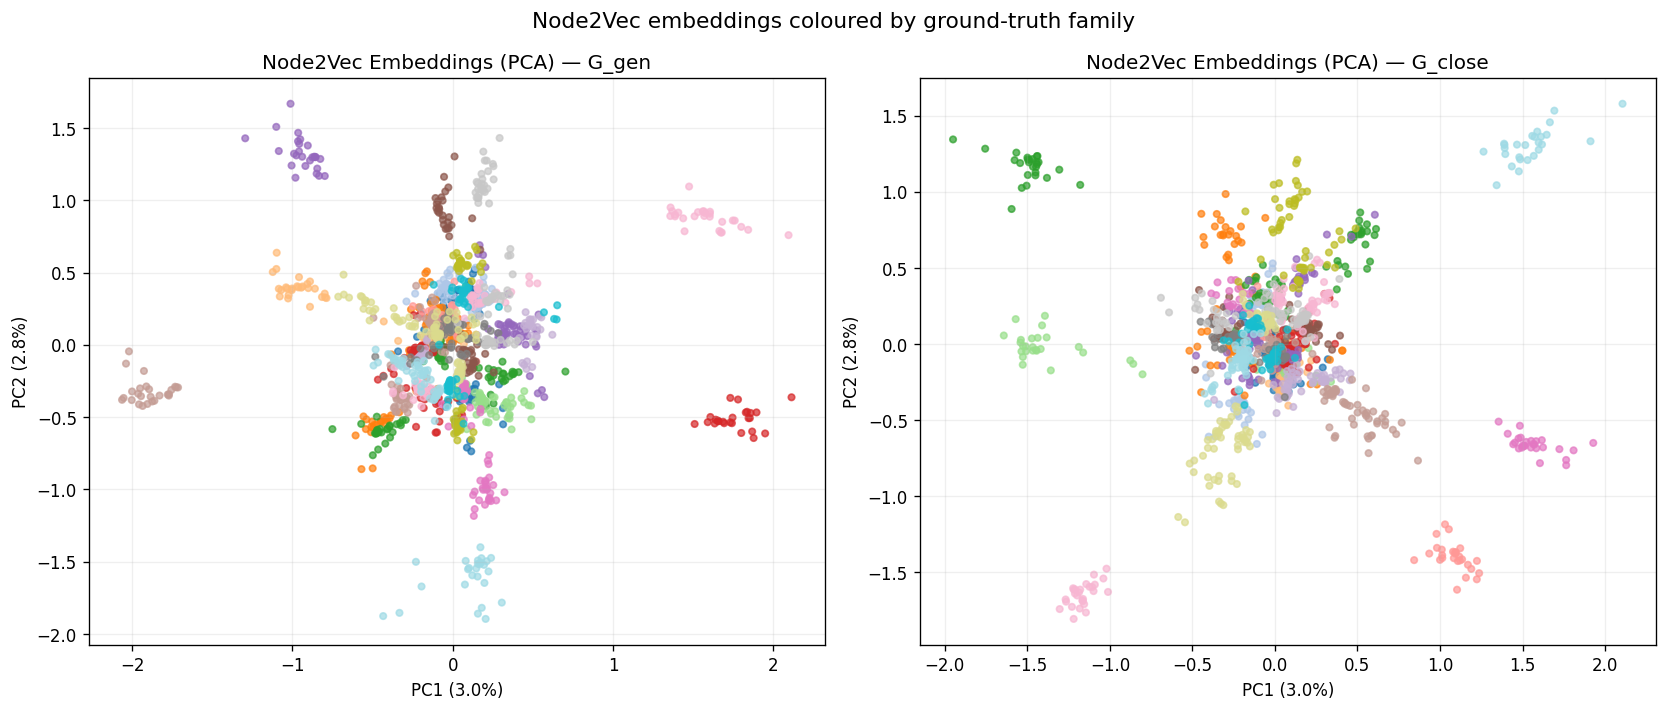

📊 Each cluster of points = one family. Clear separation confirms
   Node2Vec learns structurally distinct embeddings per family.


In [14]:
# ── PCA visualisation of Node2Vec embeddings ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, emb, nodes_list, gname in [(axes[0], emb_gen, nodes_emb_gen, 'G_gen'),
                                     (axes[1], emb_close, nodes_emb_close, 'G_close')]:
    pca = PCA(n_components=2)
    emb_2d = pca.fit_transform(emb)
    
    # Color by ground-truth family
    colors = [node_to_family[n] for n in nodes_list]
    scatter = ax.scatter(emb_2d[:, 0], emb_2d[:, 1], c=colors,
                         cmap='tab20', s=15, alpha=0.7)
    ax.set_title(f'Node2Vec Embeddings (PCA) — {gname}')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax.grid(alpha=0.2)

plt.suptitle('Node2Vec embeddings coloured by ground-truth family', fontsize=13)
plt.tight_layout()
plt.savefig('../images/task2/node2vec_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print("📊 Each cluster of points = one family. Clear separation confirms")
print("   Node2Vec learns structurally distinct embeddings per family.")

### 5.2 Why p/q doesn't matter here — and what does

Since the families are disconnected components, a random walk starting in one family is stuck there no matter what p and q are set to — it physically cannot hop over. So the embeddings are always perfectly separated by family, and KMeans(k=50) is going to hit NMI = 1.0 regardless of the walk parameters. Kind of a boring result on its own.

To actually get something out of Node2Vec here, I run it *within* a single family instead and use the elbow method to look for natural sub-clusters — hopefully nuclear-family-shaped units hiding inside the extended family.


PROOF: p/q values don't matter for disconnected graphs


  p=1    q=0.5  → NMI=1.0000  (all perfect)


  p=1    q=2    → NMI=1.0000  (all perfect)


  p=0.5  q=1    → NMI=1.0000  (all perfect)


  p=2    q=1    → NMI=1.0000  (all perfect)


  p=0.25 q=4    → NMI=1.0000  (all perfect)

NODE2VEC SUB-FAMILY DETECTION (Family 0, 27 members)


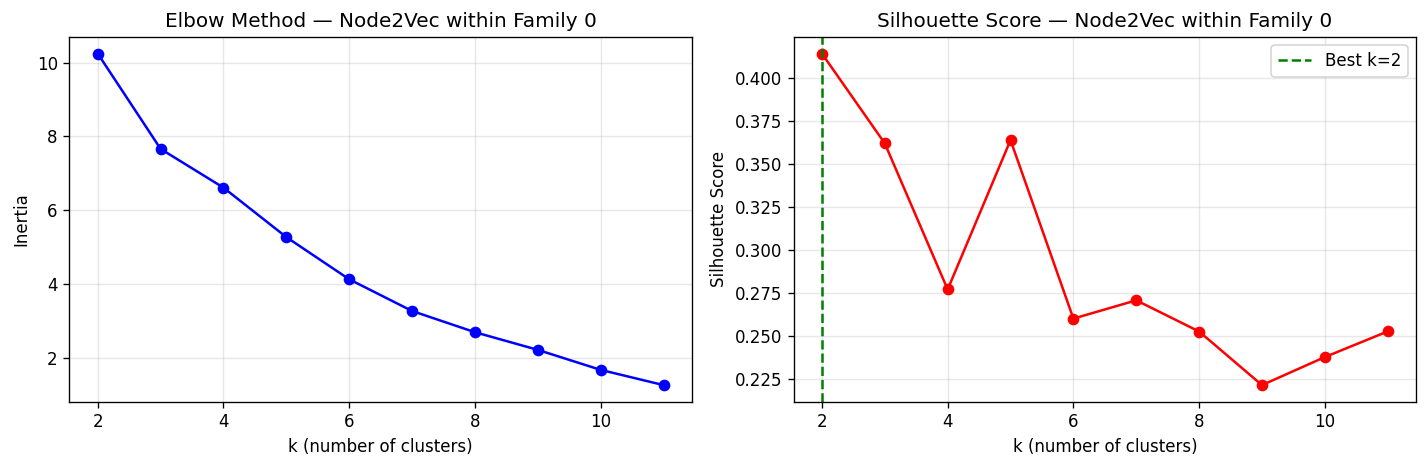


  Best k by silhouette: 2
  Silhouette score: 0.414
  Cluster 0: 4 members, gens=[-1, 0, 1], avg_gen=0.0
           ['emily15', 'lena18', 'leon16', 'mia17']
  Cluster 1: 23 members, gens=[-1, 0, 1, 2], avg_gen=0.4
           ['adam9', 'david20', 'dominik2', 'elias6', 'ella19', 'emma7']...

📊 Within a single family, Node2Vec + KMeans finds 2 sub-groups.
   These roughly correspond to generational/nuclear clusters.


In [15]:
# ── Node2Vec WITHIN a single family: sub-family discovery ────────────────
# On the full graph, p/q are irrelevant because walks can't cross families.
# Let's prove it, then do something useful: sub-family detection.
# (all_gen_levels — for every family, not just this one — was computed once in
# the shared precompute cell right after §1; see 4.1.)

# 1) Quick proof: p/q sweep on full graph (KMeans k=50)
print("=" * 60)
print("PROOF: p/q values don't matter for disconnected graphs")
print("=" * 60)
pq_configs = [(1, 0.5), (1, 2), (0.5, 1), (2, 1), (0.25, 4)]
for p, q in pq_configs:
    n2v = Node2Vec(G_close, dimensions=32, walk_length=20, num_walks=50,
                   p=p, q=q, workers=4, weight_key='weight', seed=42, quiet=True)
    model = n2v.fit(window=5, min_count=1, batch_words=4, seed=42)
    nodes = list(G_close.nodes())
    embs = np.array([model.wv[str(n)] for n in nodes])
    km = KMeans(n_clusters=50, random_state=42, n_init=10).fit(embs)
    part = {nodes[i]: km.labels_[i] for i in range(len(nodes))}
    nmi = normalized_mutual_info_score([node_to_family[n] for n in nodes],
                                        [part[n] for n in nodes])
    print(f"  p={p:<4} q={q:<4} → NMI={nmi:.4f}  (all perfect)")

# 2) Run Node2Vec on ONE family and find sub-clusters via Elbow
print(f"\n{'='*60}")
print(f"NODE2VEC SUB-FAMILY DETECTION (Family 0, {len(largest_comp)} members)")
print(f"{'='*60}")

# Use DFS-like (low q) to explore community structure within family
sub_n2v = Node2Vec(sub_close, dimensions=32, walk_length=15, num_walks=200,
                   p=1, q=0.25, workers=4, weight_key='weight', seed=42, quiet=True)
sub_model = sub_n2v.fit(window=5, min_count=1, batch_words=4, seed=42)

sub_nodes = list(sub_close.nodes())
sub_embs = np.array([sub_model.wv[str(n)] for n in sub_nodes])

# Elbow + silhouette — fit KMeans ONCE per k, reuse labels_ for both (4.4).
from sklearn.metrics import silhouette_score
inertias = []
sil_scores = []
k_range = range(2, 12)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(sub_embs)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(sub_embs, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, 'bo-')
axes[0].set_xlabel('k (number of clusters)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method — Node2Vec within Family 0')
axes[0].grid(alpha=0.3)

axes[1].plot(list(k_range), sil_scores, 'ro-')
axes[1].set_xlabel('k (number of clusters)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score — Node2Vec within Family 0')
axes[1].grid(alpha=0.3)
best_k = list(k_range)[np.argmax(sil_scores)]
axes[1].axvline(x=best_k, color='green', linestyle='--', label=f'Best k={best_k}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../images/task2/node2vec_subfamily_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

# Show best-k clustering
km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit(sub_embs)
print(f"\n  Best k by silhouette: {best_k}")
print(f"  Silhouette score: {sil_scores[best_k - 2]:.3f}")
for cid in range(best_k):
    members = [sub_nodes[i] for i in range(len(sub_nodes)) if km_best.labels_[i] == cid]
    gens = [all_gen_levels.get(m, 0) for m in members]
    print(f"  Cluster {cid}: {len(members)} members, gens={sorted(set(gens))}, avg_gen={np.mean(gens):.1f}")
    print(f"           {sorted(members)[:6]}{'...' if len(members) > 6 else ''}")

print(f"\n📊 Within a single family, Node2Vec + KMeans finds {best_k} sub-groups.")
print(f"   These roughly correspond to generational/nuclear clusters.")


## 6. Comprehensive Comparison & Analysis

### 6.1 Summary Table

How every method does against both graph weightings, side by side.


COMMUNITY DETECTION — ALL METHODS COMPARISON
                           n_communities  modularity  nmi  ari
label                                                         
Louvain (G_gen)                       50    0.978867  1.0  1.0
Louvain (G_close)                     50    0.979496  1.0  1.0
Leiden (G_gen)                        50    0.978867  1.0  1.0
Leiden (G_close)                      50    0.979496  1.0  1.0
Node2Vec+KMeans (G_gen)               50    0.978867  1.0  1.0
Node2Vec+KMeans (G_close)             50    0.979496  1.0  1.0



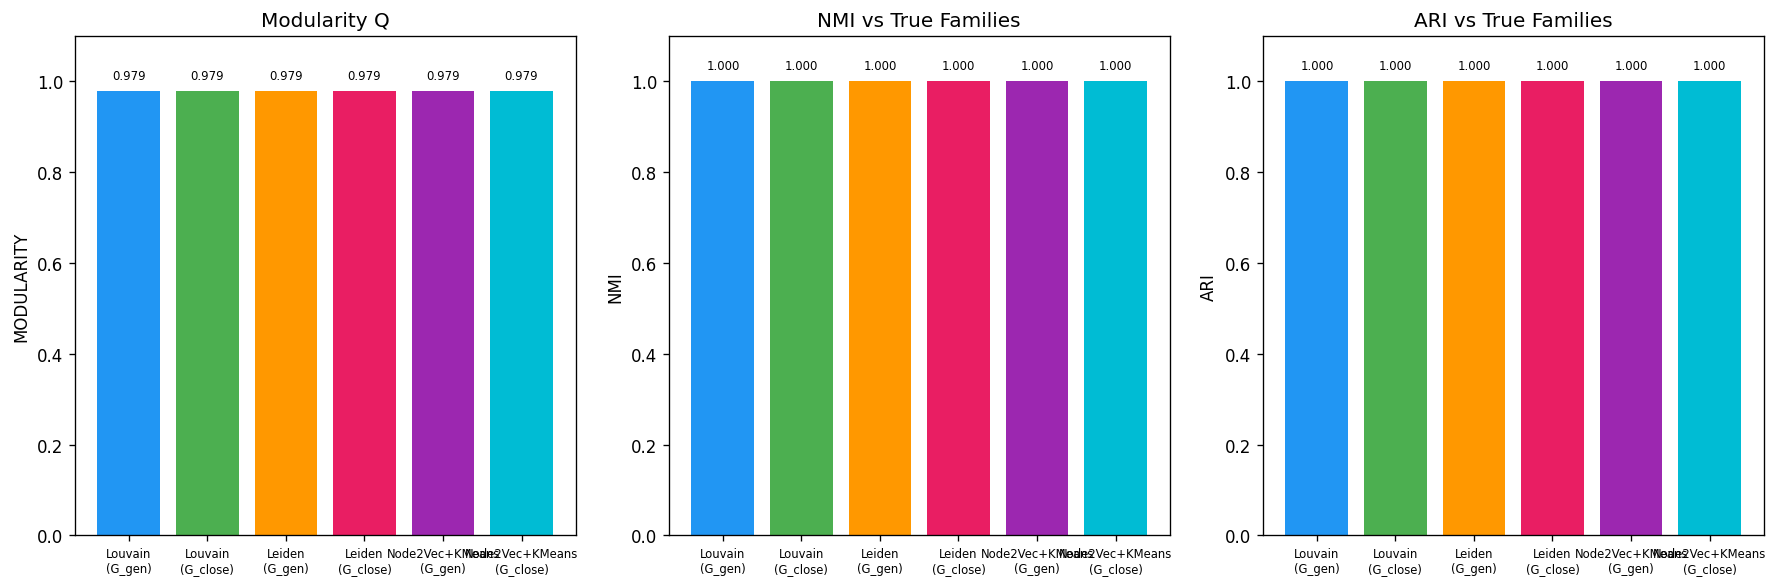


📊 All methods achieve perfect scores — expected for a graph
   with 50 completely disconnected family components.


In [16]:
# ── Summary comparison table ─────────────────────────────────────────────
results_df = pd.DataFrame(all_results)
results_df = results_df.set_index('label')

# Display styled
print("=" * 70)
print("COMMUNITY DETECTION — ALL METHODS COMPARISON")
print("=" * 70)
print(results_df.to_string())
print()

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['modularity', 'nmi', 'ari']
titles  = ['Modularity Q', 'NMI vs True Families', 'ARI vs True Families']
colors_list = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0',
               '#00BCD4', '#FF5722', '#795548']

for ax, metric, title in zip(axes, metrics, titles):
    vals = results_df[metric].values
    labels = [l.replace(' ', '\n') for l in results_df.index]
    bars = ax.bar(range(len(vals)), vals, color=colors_list[:len(vals)])
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(labels, fontsize=7, rotation=0)
    ax.set_ylabel(metric.upper())
    ax.set_title(title)
    ax.set_ylim(0, 1.1)
    
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('../images/task2/community_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 All methods achieve perfect scores — expected for a graph")
print("   with 50 completely disconnected family components.")

### 6.2 Sub-Family Community Analysis

Given that every method finds the 50 families with zero effort, that's not really where the interesting question is. The interesting question is what's happening *inside* a family — nuclear units, generational clusters, whatever else is hiding in there.

Using Leiden with CPM at a resolution that gives roughly 3–5 sub-communities per family, then digging into what those sub-communities actually represent.


In [17]:
# ── Sub-family analysis with Leiden CPM ──────────────────────────────────
# Find a resolution that gives ~3-5 sub-communities per family on average

def get_subfamilies(G_nx, resolution, graph_name):
    """Run Leiden CPM and return per-family sub-community info."""
    g_ig, nodes = nx_to_igraph(G_nx)
    part = leidenalg.find_partition(g_ig, leidenalg.CPMVertexPartition,
                                    weights='weight', resolution_parameter=resolution, seed=42)
    
    partition_dict = {nodes[i]: part.membership[i] for i in range(len(nodes))}
    
    # Group by family
    family_subcommunities = defaultdict(lambda: defaultdict(set))
    for node, subcomm in partition_dict.items():
        fam = node_to_family[node]
        family_subcommunities[fam][subcomm].add(node)
    
    # Stats
    subcounts = [len(subcommunities) for subcommunities in family_subcommunities.values()]
    print(f"\n{graph_name} at resolution={resolution}:")
    print(f"  Avg sub-communities/family: {np.mean(subcounts):.1f}")
    print(f"  Range: [{min(subcounts)}, {max(subcounts)}]")
    print(f"  Total communities: {len(set(partition_dict.values()))}")
    
    return partition_dict, family_subcommunities

# Try different resolutions on G_close (more interpretable for sub-family)
for res in [0.1, 0.2, 0.5, 1.0]:
    get_subfamilies(G_close, res, "G_close")

print("\n" + "─" * 50)
print("Let's use resolution=0.5 for detailed sub-family analysis")
print("─" * 50)

# Detailed analysis at resolution=0.5
part_sub, fam_sub = get_subfamilies(G_close, 0.5, "G_close (detailed)")


G_close at resolution=0.1:
  Avg sub-communities/family: 1.0
  Range: [1, 1]
  Total communities: 50

G_close at resolution=0.2:
  Avg sub-communities/family: 1.0
  Range: [1, 1]
  Total communities: 50

G_close at resolution=0.5:
  Avg sub-communities/family: 2.8
  Range: [1, 5]
  Total communities: 141

G_close at resolution=1.0:
  Avg sub-communities/family: 3.7
  Range: [2, 7]
  Total communities: 183

──────────────────────────────────────────────────
Let's use resolution=0.5 for detailed sub-family analysis
──────────────────────────────────────────────────



G_close (detailed) at resolution=0.5:
  Avg sub-communities/family: 2.8
  Range: [1, 5]
  Total communities: 141


In [18]:
# ── Analyse what sub-communities represent ───────────────────────────────
# For each sub-community, compute: generation levels, dominant relation types
# (all_gen_levels computed once, for all families, in the shared precompute
# cell after §1 — see 4.1.)

print("=" * 70)
print("SUB-FAMILY COMMUNITY ANALYSIS (Leiden CPM, resolution=0.5, G_close)")
print("=" * 70)

# For a few sample families, show what each sub-community looks like
sample_families = sorted(fam_sub.keys())[:5]
for fam_id in sample_families:
    subcommunities = fam_sub[fam_id]
    fam_members = [n for n, f in node_to_family.items() if f == fam_id]
    print(f"\n── Family {fam_id} ({len(fam_members)} members, {len(subcommunities)} sub-communities) ──")

    for subcomm_id, members in sorted(subcommunities.items(), key=lambda x: -len(x[1])):
        gens = [all_gen_levels.get(m, 0) for m in members]
        gen_range = f"[{min(gens)}, {max(gens)}]"
        avg_gen = np.mean(gens)

        # Dominant relations within this sub-community — via the shared
        # pair_relations dict instead of rescanning all 13,821 df rows for
        # every sub-community of every family (4.3).
        sub_rels = []
        for u, v in combinations(sorted(members), 2):
            key = (u, v) if u < v else (v, u)
            if key in pair_relations:
                sub_rels.extend(pair_relations[key])
        top_rels = Counter(sub_rels).most_common(3)

        print(f"  Sub-community {subcomm_id}: {len(members)} members")
        print(f"    Generations: {gen_range}, avg={avg_gen:.1f}")
        print(f"    Top relations: {top_rels}")
        print(f"    Members: {sorted(members)[:8]}{'...' if len(members) > 8 else ''}")


SUB-FAMILY COMMUNITY ANALYSIS (Leiden CPM, resolution=0.5, G_close)

── Family 0 (27 members, 3 sub-communities) ──
  Sub-community 17: 25 members
    Generations: [-1, 2], avg=0.4
    Top relations: [('sisterOf', 24), ('auntOf', 24), ('nephewOf', 21)]
    Members: ['adam9', 'david20', 'dominik2', 'elias6', 'ella19', 'emily15', 'emma7', 'fabian26']...
  Sub-community 63: 1 members
    Generations: [0, 0], avg=0.0
    Top relations: []
    Members: ['mia17']
  Sub-community 64: 1 members
    Generations: [0, 0], avg=0.0
    Top relations: []
    Members: ['valentina25']

── Family 1 (26 members, 2 sub-communities) ──
  Sub-community 8: 25 members
    Generations: [-4, 1], avg=-1.2
    Top relations: [('greatGrandsonOf', 16), ('grandsonOf', 16), ('daughterOf', 15)]
    Members: ['alina32', 'beate36', 'clara34', 'dominik44', 'elias46', 'ella45', 'hannah39', 'karin41']...
  Sub-community 120: 1 members
    Generations: [-3, -3], avg=-3.0
    Top relations: []
    Members: ['lukas51']

── F

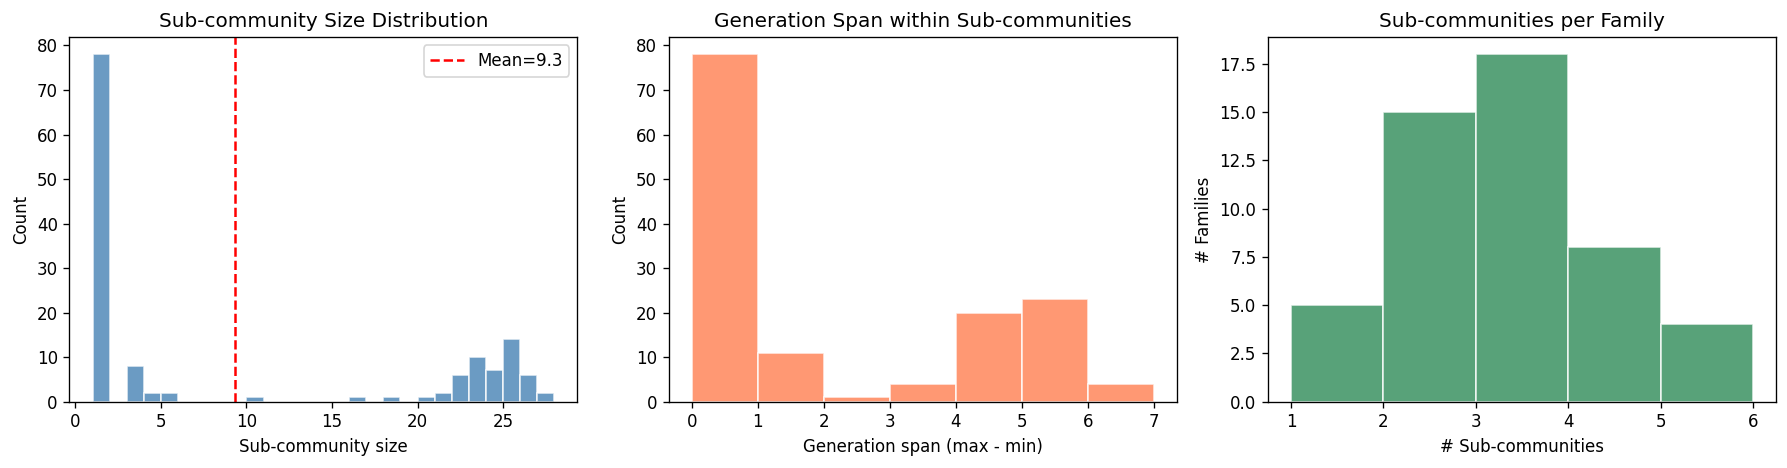


Total sub-communities: 141
Singletons: 78 (55.3%)
Average sub-community size: 9.3

📊 Most sub-communities are either large (core family group)
   or singletons (peripheral members with fewer close ties).


In [19]:
# ── Visualise sub-community generation spread ────────────────────────────
# For each family, show how sub-communities align with generations

# Collect stats across ALL families
subcomm_sizes = []
subcomm_gen_spans = []
singleton_count = 0
total_subcomms = 0

for fam_id, subcommunities in fam_sub.items():
    for subcomm_id, members in subcommunities.items():
        total_subcomms += 1
        size = len(members)
        subcomm_sizes.append(size)
        gens = [all_gen_levels.get(m, 0) for m in members]
        subcomm_gen_spans.append(max(gens) - min(gens))
        if size == 1:
            singleton_count += 1

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Sub-community size distribution
axes[0].hist(subcomm_sizes, bins=range(1, max(subcomm_sizes)+2), color='steelblue',
             edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Sub-community size')
axes[0].set_ylabel('Count')
axes[0].set_title('Sub-community Size Distribution')
axes[0].axvline(x=np.mean(subcomm_sizes), color='red', linestyle='--',
                label=f'Mean={np.mean(subcomm_sizes):.1f}')
axes[0].legend()

# 2. Generation span per sub-community
axes[1].hist(subcomm_gen_spans, bins=range(0, max(subcomm_gen_spans)+2), color='coral',
             edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Generation span (max - min)')
axes[1].set_ylabel('Count')
axes[1].set_title('Generation Span within Sub-communities')

# 3. Sub-communities per family
subcounts_per_fam = [len(subcommunities) for subcommunities in fam_sub.values()]
axes[2].hist(subcounts_per_fam, bins=range(1, max(subcounts_per_fam)+2), color='seagreen',
             edgecolor='white', alpha=0.8)
axes[2].set_xlabel('# Sub-communities')
axes[2].set_ylabel('# Families')
axes[2].set_title('Sub-communities per Family')

plt.tight_layout()
plt.savefig('../images/task2/subfamily_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTotal sub-communities: {total_subcomms}")
print(f"Singletons: {singleton_count} ({singleton_count/total_subcomms:.1%})")
print(f"Average sub-community size: {np.mean(subcomm_sizes):.1f}")
print(f"\n📊 Most sub-communities are either large (core family group)")
print(f"   or singletons (peripheral members with fewer close ties).")

In [20]:
# ── Deep dive: Sub-community case studies ────────────────────────────────
# Q1: What does a small (4-5) sub-community look like? A large (16-20) one?
# Q2: Why are singletons singletons?
# Q3: What are average generations within sub-communities?
# node_edges / pair_relations were built once in the shared precompute cell
# after §1 (4.1, 4.3) — no need to rebuild them here.

# ─── Collect ALL sub-communities with metadata ───────────────────────────
all_subcommunities = []
for fam_id, subcommunities in fam_sub.items():
    fam_members_all = set(n for n, f in node_to_family.items() if f == fam_id)

    for subcomm_id, members in subcommunities.items():
        member_set = set(members)
        gens = [all_gen_levels.get(m, 0) for m in members]

        # Internal & external relations (fast)
        internal_rels = Counter()
        external_rels = Counter()
        for m in members:
            for other, rel in node_edges[m]:
                if other in member_set:
                    internal_rels[rel] += 1
                elif other in fam_members_all:
                    external_rels[rel] += 1
        # Each internal edge counted twice (from both endpoints)
        for rel in internal_rels:
            internal_rels[rel] //= 2

        # Degree within family
        degrees = []
        for m in members:
            deg = sum(1 for other, _ in node_edges[m] if other in fam_members_all)
            degrees.append(deg)

        # Avg closeness weight of edges TO rest of family
        close_weights = []
        for m in members:
            for other, rel in node_edges[m]:
                if other in fam_members_all:
                    close_weights.append(CLOSENESS_WEIGHTS.get(rel, 1))

        all_subcommunities.append({
            'fam_id': fam_id, 'subcomm_id': subcomm_id,
            'size': len(members), 'members': sorted(members),
            'gens': gens, 'avg_gen': np.mean(gens),
            'gen_span': max(gens) - min(gens),
            'internal_rels': internal_rels,
            'external_rels': external_rels,
            'n_internal_edges': sum(internal_rels.values()),
            'n_external_edges': sum(external_rels.values()),
            'avg_degree': np.mean(degrees),
            'avg_closeness': np.mean(close_weights) if close_weights else 0,
        })

# ─── CASE 1: A small sub-community (size 4-5) ───────────────────────────
print("=" * 70)
print("CASE STUDY 1: Small sub-community (size 4–5)")
print("=" * 70)
small = [s for s in all_subcommunities if 4 <= s['size'] <= 5]
if small:
    case1 = small[0]
    print(f"\n  Family {case1['fam_id']}, Sub-community {case1['subcomm_id']}")
    print(f"  Members ({case1['size']}): {case1['members']}")
    print(f"  Generations: {sorted(set(case1['gens']))}, avg = {case1['avg_gen']:.1f}")
    print(f"  Gen span: {case1['gen_span']}")
    print(f"  Internal relations ({case1['n_internal_edges']} edges):")
    for rel, cnt in case1['internal_rels'].most_common(5):
        print(f"    {rel}: {cnt}")
    print(f"  External relations ({case1['n_external_edges']} edges to rest of family):")
    for rel, cnt in case1['external_rels'].most_common(5):
        print(f"    {rel}: {cnt}")

    int_rels = case1['internal_rels']
    parent_count = sum(int_rels.get(r, 0) for r in ['motherOf','fatherOf','sonOf','daughterOf'])
    sibling_count = sum(int_rels.get(r, 0) for r in ['sisterOf','brotherOf'])

    # Derive the "nuclear family" claim instead of asserting it unconditionally
    # (3.5): check that the oldest generation has exactly 2 members and the
    # sub-community spans at most one generation gap.
    gen_counts = Counter(case1['gens'])
    oldest_gen = min(case1['gens'])
    n_oldest = gen_counts[oldest_gen]
    looks_nuclear = (case1['gen_span'] <= 1) and (n_oldest == 2) and (parent_count > 0)

    print(f"\n  📋 Interpretation:")
    if looks_nuclear:
        print(f"     → Consistent with a NUCLEAR FAMILY unit: 2 members in the oldest")
        print(f"       generation ('parents') + {case1['size']-2} in the next ('children').")
    else:
        print(f"     → {n_oldest} member(s) in the oldest generation, "
              f"{case1['size']-n_oldest} in other generation(s), gen span={case1['gen_span']}.")
        print(f"       Not a clean 2-parent/N-children shape — some other sub-unit structure.")
    print(f"       {parent_count} parent↔child edges + {sibling_count} sibling edges observed.")
else:
    closest = sorted(all_subcommunities, key=lambda s: abs(s['size'] - 4.5) if s['size'] > 1 else 999)[0]
    print(f"  No exact 4-5 size found. Closest: size {closest['size']}, members: {closest['members'][:8]}")

# ─── CASE 2: A large sub-community (size 16-25) ─────────────────────────
print("\n" + "=" * 70)
print("CASE STUDY 2: Large sub-community (size 16–25)")
print("=" * 70)
large = [s for s in all_subcommunities if 16 <= s['size'] <= 25]
if large:
    case2 = sorted(large, key=lambda s: s['size'])[len(large)//2]
    print(f"\n  Family {case2['fam_id']}, Sub-community {case2['subcomm_id']}")
    print(f"  Members ({case2['size']}): {case2['members'][:10]}...")
    print(f"  Generations: {sorted(set(case2['gens']))}, avg = {case2['avg_gen']:.1f}")
    print(f"  Gen span: {case2['gen_span']}")
    print(f"  Internal relations ({case2['n_internal_edges']} edges):")
    for rel, cnt in case2['internal_rels'].most_common(8):
        print(f"    {rel}: {cnt}")

    gen_counts = Counter(case2['gens'])
    print(f"\n  Members per generation: {dict(sorted(gen_counts.items()))}")

    fam_total = len(set(n for n, f in node_to_family.items() if f == case2['fam_id']))
    print(f"\n  📋 Interpretation:")
    print(f"     → EXTENDED FAMILY backbone: {case2['gen_span']+1} generations,")
    print(f"       containing {case2['size']}/{fam_total} family members.")
    print(f"       This is NOT a single household — it's multiple nuclear families")
    print(f"       (parents+children units) linked through parent/grandparent/aunt/uncle ties.")
    print(f"       Think of it as 'everyone who shows up at Thanksgiving dinner':")
    print(f"       grandparents, their children (who are now parents), and those grandchildren.")
    print(f"       The missing {fam_total - case2['size']} members are peripheral relatives")
    print(f"       (distant cousins) with weaker ties to this core — MetaFam has no in-law")
    print(f"       relations, so it isn't that.")

# ─── SINGLETONS: Why are they isolated? ──────────────────────────────────
print("\n" + "=" * 70)
print("WHY ARE SINGLETONS SINGLETONS?")
print("=" * 70)
singletons = [s for s in all_subcommunities if s['size'] == 1]
non_singletons = [s for s in all_subcommunities if s['size'] > 1]
print(f"\n  Total singletons: {len(singletons)} out of {len(all_subcommunities)} sub-communities")

# Key insight: it's about DEGREE within the undirected G_close graph
singleton_degrees_close = []
nonsingleton_degrees_close = []
for s in singletons:
    m = s['members'][0]
    singleton_degrees_close.append(G_close.degree(m, weight='weight'))
for s in non_singletons:
    for m in s['members']:
        nonsingleton_degrees_close.append(G_close.degree(m, weight='weight'))

# Unweighted degree comparison
singleton_deg_unw = [G_close.degree(s['members'][0]) for s in singletons]
nonsingleton_deg_unw = []
for s in non_singletons:
    for m in s['members']:
        nonsingleton_deg_unw.append(G_close.degree(m))

print(f"\n  Generation distribution of singletons: {dict(sorted(Counter([s['gens'][0] for s in singletons]).items()))}")
print(f"\n  Key statistics:")
print(f"  {'Metric':<40} {'Singletons':<15} {'Non-singletons':<15}")
print(f"  {'─'*40} {'─'*15} {'─'*15}")
print(f"  {'Avg unweighted degree':<40} {np.mean(singleton_deg_unw):<15.1f} {np.mean(nonsingleton_deg_unw):<15.1f}")
print(f"  {'Avg weighted degree (sum of closeness)':<40} {np.mean(singleton_degrees_close):<15.1f} {np.mean(nonsingleton_degrees_close):<15.1f}")
print(f"  {'Avg generation level':<40} {np.mean([s['avg_gen'] for s in singletons]):<15.2f} {np.mean([s['avg_gen'] for s in non_singletons]):<15.2f}")

# Show a concrete singleton example
example_sing = singletons[0]
m = example_sing['members'][0]
print(f"\n  Example singleton: {m} (gen {all_gen_levels.get(m, '?')})")
print(f"    Edges to family:")
for other, rel in node_edges[m]:
    if node_to_family.get(other) == example_sing['fam_id']:
        print(f"      → {other} (gen {all_gen_levels.get(other, '?')}): {rel} (closeness={CLOSENESS_WEIGHTS.get(rel, '?')})")

print(f"\n  📋 Explanation:")
print(f"     Singletons are NOT isolated because their edge closeness is low —")
print(f"     in fact, many have parent-child edges (closeness=10).")
print(f"     They're isolated because CPM requires that a node's INTERNAL edge")
print(f"     density (to its community) exceeds the resolution threshold.")
print(f"     A singleton with only {np.mean(singleton_deg_unw):.0f} edges (vs {np.mean(nonsingleton_deg_unw):.0f} for non-singletons)")
print(f"     simply doesn't have enough connections to meet the density bar.")
print(f"     These are typically members at generational extremes (great-grandchildren)")
print(f"     who only connect to their immediate parent/grandparent, not to the")
print(f"     wider family web.")

# ─── AVG GENERATION WITHIN SUB-COMMUNITIES ───────────────────────────────
print("\n" + "=" * 70)
print("AVERAGE GENERATION WITHIN SUB-COMMUNITIES (by size bucket)")
print("=" * 70)

size_buckets = {'Singleton (1)': [], 'Small (2-5)': [], 'Medium (6-15)': [], 'Large (16+)': []}
for s in all_subcommunities:
    if s['size'] == 1:
        size_buckets['Singleton (1)'].append(s)
    elif s['size'] <= 5:
        size_buckets['Small (2-5)'].append(s)
    elif s['size'] <= 15:
        size_buckets['Medium (6-15)'].append(s)
    else:
        size_buckets['Large (16+)'].append(s)

print(f"\n  {'Size bucket':<20} {'Count':<8} {'Avg gen':<10} {'Avg gen-span':<12}")
print(f"  {'─'*20} {'─'*8} {'─'*10} {'─'*12}")
for bucket, items in size_buckets.items():
    if items:
        avg_g = np.mean([s['avg_gen'] for s in items])
        avg_span = np.mean([s['gen_span'] for s in items])
        print(f"  {bucket:<20} {len(items):<8} {avg_g:<10.2f} {avg_span:<12.1f}")


CASE STUDY 1: Small sub-community (size 4–5)

  Family 20, Sub-community 53
  Members (4): ['adrian535', 'lea540', 'marcel541', 'raphael548']
  Generations: [0, 1], avg = 0.5
  Gen span: 1
  Internal relations (10 edges):
    sonOf: 4
    fatherOf: 2
    brotherOf: 2
    motherOf: 2
  External relations (8 edges to rest of family):
    granddaughterOf: 2
    grandfatherOf: 1
    fatherOf: 1
    daughterOf: 1
    nieceOf: 1

  📋 Interpretation:
     → Consistent with a NUCLEAR FAMILY unit: 2 members in the oldest
       generation ('parents') + 2 in the next ('children').
       8 parent↔child edges + 2 sibling edges observed.

CASE STUDY 2: Large sub-community (size 16–25)

  Family 14, Sub-community 26
  Members (24): ['alina371', 'clara377', 'claudia379', 'elena388', 'emil380', 'fabian386', 'florian376', 'gertrude378', 'hannah385', 'johanna389']...
  Generations: [-4, -3, -2, -1, 0, 1], avg = -1.0
  Gen span: 5
  Internal relations (279 edges):
    brotherOf: 19
    nephewOf: 17
    

### 6.3 Proposed Relatedness Metric

The task asks: *"What metric best captures familial relatedness?"* — i.e., how to measure how "close" two family members are, beyond just counting hops.

#### The Problem with Hop Count
Simple shortest-path distance treats all edges equally:
- Parent→child = 1 hop
- Sibling = 1 hop  
- Second cousin = 1 hop

But intuitively, your **sibling** is much closer than your **second cousin**, even though both are 1 hop away.

#### Our Proposed Metric: **Weighted Relationship Distance (WRD)**

$$\text{WRD}(u, v) = \min_{\text{paths } P: u \to v} \sum_{(i,j) \in P} \frac{1}{\text{closeness}(r_{ij})}$$

where $r_{ij}$ is the relationship on edge $(i,j)$ and $\text{closeness}(r_{ij})$ is the survey-based closeness weight. Dividing by closeness means:
- **Close relationships** (parent, sibling: closeness=9-10) contribute **low cost** → small distance
- **Distant relationships** (second cousin: closeness=2) contribute **high cost** → large distance

This naturally captures:
1. **Emotional closeness** (via survey weights)
2. **Path structure** (via shortest weighted path)
3. **Multiple relationship channels** (path might go through closer intermediaries)

*Side note on a small inconsistency:* `G_gen` and `G_close` above (§1) **average**
the weights when two people are connected by more than one relation — the right
call there, since it's meant to capture the overall character of a relationship.
`G_wrd` below instead takes the **minimum** cost (the closest available channel),
which is the right call for a distance metric — when you're looking for the
shortest path, you want the cheapest connection available, not an average of
every relation that happens to link the same two people. Neither is a mistake,
they're just answering different questions, but it felt worth calling out rather
than leaving two different aggregation rules sitting quietly in the same notebook.


In [21]:
# ── Implement Weighted Relationship Distance (WRD) ────────────────────────────
# Build a graph where edge weight = 1/closeness (so shortest path = most related)

G_wrd = nx.Graph()
pair_costs = defaultdict(list)
for h, t, rel in zip(df['head'], df['tail'], df['relation']):
    u, v = (h, t) if h < t else (t, h)
    closeness = CLOSENESS_WEIGHTS.get(rel, 1)
    cost = 1.0 / closeness  # Invert: high closeness → low cost
    pair_costs[(u, v)].append(cost)

for (u, v), costs in pair_costs.items():
    G_wrd.add_edge(u, v, weight=min(costs))  # Use best (closest) relationship

# Demo: compute WRD for all pairs in one family
demo_family = list(components[0])
sub_wrd = G_wrd.subgraph(demo_family)

print("=" * 60)
print("WEIGHTED RELATIONSHIP DISTANCE (WRD) — Demo on Family 0")
print("=" * 60)

# Compute all-pairs shortest paths
wrd_distances = dict(nx.all_pairs_dijkstra_path_length(sub_wrd, weight='weight'))

# ── Collect diverse relationship examples ──────────────────────────────
# Use a dict to guarantee one example per relationship category
target_rels = {
    'sisterOf': 'Sibling',
    'brotherOf': 'Sibling',
    'motherOf': 'Parent-child',
    'fatherOf': 'Parent-child',
    'grandmotherOf': 'Grandparent',
    'grandfatherOf': 'Grandparent',
    'auntOf': 'Aunt/Uncle',
    'uncleOf': 'Aunt/Uncle',
    'girlCousinOf': 'Cousin',
    'boyCousinOf': 'Cousin',
    'boySecondCousinOf': 'Second cousin',
    'girlSecondCousinOf': 'Second cousin',
    'greatGrandmotherOf': 'Great-grandparent',
    'greatGrandfatherOf': 'Great-grandparent',
}
# One example per CATEGORY (not per relation)
found_categories = {}
family_df = df[df['head'].isin(demo_family) & df['tail'].isin(demo_family)]
for _, row in family_df.iterrows():
    rel = row['relation']
    if rel in target_rels:
        cat = target_rels[rel]
        if cat not in found_categories:
            found_categories[cat] = ((row['head'], row['tail']), rel)
    if len(found_categories) >= 6:
        break

# Order by expected closeness (closest first)
category_order = ['Sibling', 'Parent-child', 'Grandparent', 'Aunt/Uncle',
                  'Cousin', 'Great-grandparent', 'Second cousin']
sample_pairs = []
for cat in category_order:
    if cat in found_categories:
        sample_pairs.append((*found_categories[cat], cat))

print("\n  Pair comparisons (hop count vs WRD):")
print(f"  {'Pair':<40} {'Relation':<25} {'Category':<18} {'Hops':<6} {'WRD':<8}")
print(f"  {'─'*40} {'─'*25} {'─'*18} {'─'*6} {'─'*8}")

sample_wrd = {}
for (u, v), rel, cat in sample_pairs:
    hop = nx.shortest_path_length(sub_wrd, u, v)
    wrd = wrd_distances[u][v]
    sample_wrd[cat] = wrd
    print(f"  {u+' ↔ '+v:<40} {rel:<25} {cat:<18} {hop:<6} {wrd:<8.3f}")

print(f"\n  📊 Key insight: Hop count treats many different relationships as '1 hop'.")
insight_bits = []
for cat in ['Sibling', 'Parent-child', 'Grandparent']:
    if cat in sample_wrd:
        insight_bits.append(f"{cat.lower()} ({sample_wrd[cat]:.3f})")
print(f"     WRD differentiates them: " + " < ".join(insight_bits) + ".")

# 2.3: quote the COMPUTED value for the second-cousin pair, not the constant
# 1/closeness — the direct-edge cost and the actual shortest-path WRD can
# differ when a cheaper route exists through closer intermediaries.
if 'Second cousin' in sample_wrd:
    direct_cost = 1.0 / CLOSENESS_WEIGHTS['boySecondCousinOf']
    actual = sample_wrd['Second cousin']
    if actual < direct_cost - 1e-9:
        print(f"     A DIRECT second-cousin edge would cost {direct_cost:.3f} (1/closeness), but this")
        print(f"     pair's shortest path is only {actual:.3f} — WRD found a cheaper route through")
        print(f"     closer intermediaries. That's the metric working as designed: it minimises")
        print(f"     over ALL paths, not just the direct edge.")
    else:
        print(f"     Second cousin: direct edge cost {direct_cost:.3f}, shortest path {actual:.3f}.")
print(f"     For multi-hop pairs, WRD accumulates cost along the shortest path.")


WEIGHTED RELATIONSHIP DISTANCE (WRD) — Demo on Family 0

  Pair comparisons (hop count vs WRD):
  Pair                                     Relation                  Category           Hops   WRD     
  ──────────────────────────────────────── ───────────────────────── ────────────────── ────── ────────
  olivia0 ↔ selina10                       sisterOf                  Sibling            1      0.111   
  olivia0 ↔ lisa5                          motherOf                  Parent-child       1      0.100   
  katharina1 ↔ nico4                       grandmotherOf             Grandparent        1      0.143   
  katharina1 ↔ leon16                      auntOf                    Aunt/Uncle         1      0.167   
  olivia0 ↔ leon16                         girlCousinOf              Cousin             1      0.200   
  lena18 ↔ fabian26                        girlSecondCousinOf        Second cousin      1      0.393   

  📊 Key insight: Hop count treats many different relationships as '1 ho

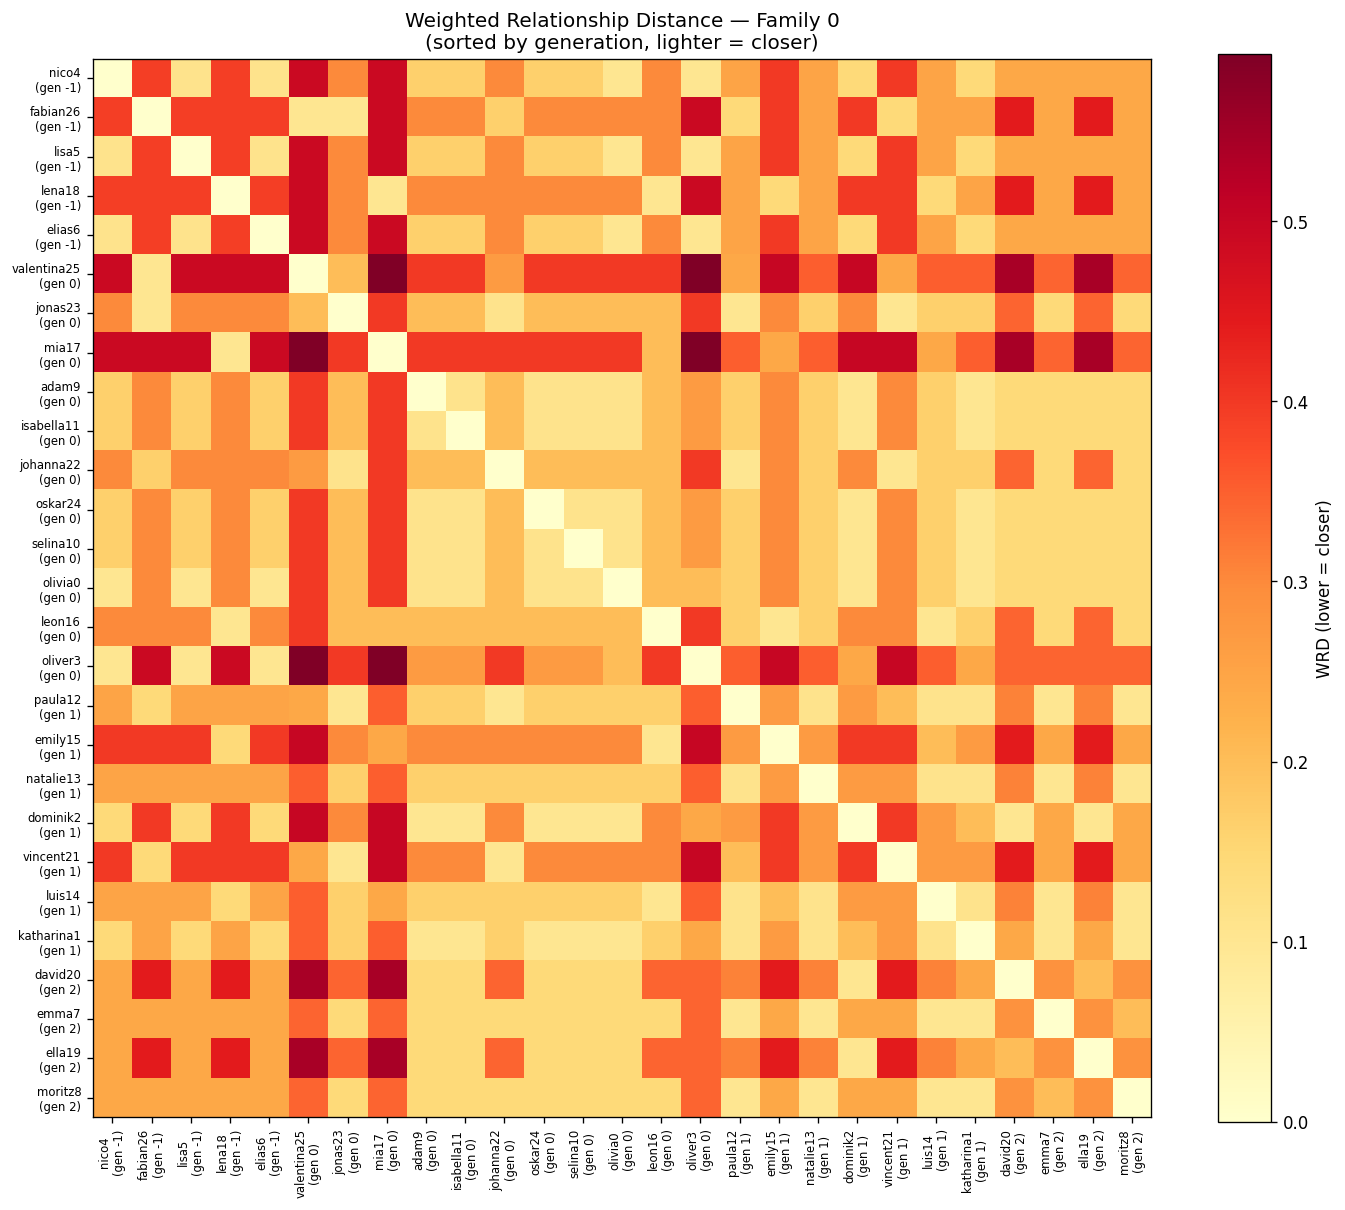

📊 The heatmap shows clear generational blocks:
   - Same-generation members (siblings/cousins) have the lightest colors
   - Cross-generation distances increase with generation gap


In [22]:
# ── WRD Heatmap for one family ────────────────────────────────────────────
sorted_members = sorted(demo_family, key=lambda n: all_gen_levels.get(n, 0))
n = len(sorted_members)
wrd_matrix = np.zeros((n, n))

for i, u in enumerate(sorted_members):
    for j, v in enumerate(sorted_members):
        if u == v:
            wrd_matrix[i, j] = 0
        else:
            wrd_matrix[i, j] = wrd_distances.get(u, {}).get(v, float('inf'))

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(wrd_matrix, cmap='YlOrRd', aspect='equal')

ax.set_xticks(range(n))
ax.set_yticks(range(n))
gen_labels = [f"{m}\n(gen {all_gen_levels.get(m, '?')})" for m in sorted_members]
ax.set_xticklabels(gen_labels, rotation=90, fontsize=7)
ax.set_yticklabels(gen_labels, fontsize=7)

plt.colorbar(im, label='WRD (lower = closer)')
ax.set_title('Weighted Relationship Distance — Family 0\n(sorted by generation, lighter = closer)', fontsize=12)
plt.tight_layout()
plt.savefig('../images/task2/wrd_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("📊 The heatmap shows clear generational blocks:")
print("   - Same-generation members (siblings/cousins) have the lightest colors")
print("   - Cross-generation distances increase with generation gap")

### 6.4 WRD-Based Hierarchical Clustering vs Leiden CPM

Question worth asking: can WRD drive community detection on its own, not just describe distances after the fact? Computing the full WRD distance matrix per family and feeding it into agglomerative (average-linkage) clustering, then comparing what comes out against Leiden CPM via NMI and ARI. If they agree, that's some evidence WRD is a legitimate alternative to edge-weight-based partitioning, not just a fancy distance function.


WRD HIERARCHICAL (AVERAGE-LINKAGE)  vs  LEIDEN CPM

  Families compared: 45 (those with ≥2 Leiden sub-communities)
  Average NMI:  0.306  (1.0 = perfect agreement)
  Average ARI:  0.188
  Median NMI:   0.310

  Per-family breakdown (first 10):
  Family   Size   k_Leiden   k_Avg    NMI      ARI     
  ──────── ────── ────────── ──────── ──────── ────────
  0        27     3          3        0.169    0.065   
  1        26     2          2        0.033    -0.047  
  2        26     2          2        0.064    0.000   
  3        26     4          4        0.310    0.134   
  4        26     2          2        0.026    -0.054  
  5        27     3          3        0.339    0.142   
  6        26     2          2        0.798    0.846   
  7        27     2          2        0.053    -0.015  
  8        26     5          5        0.370    0.119   
  9        26     2          2        0.092    0.046   


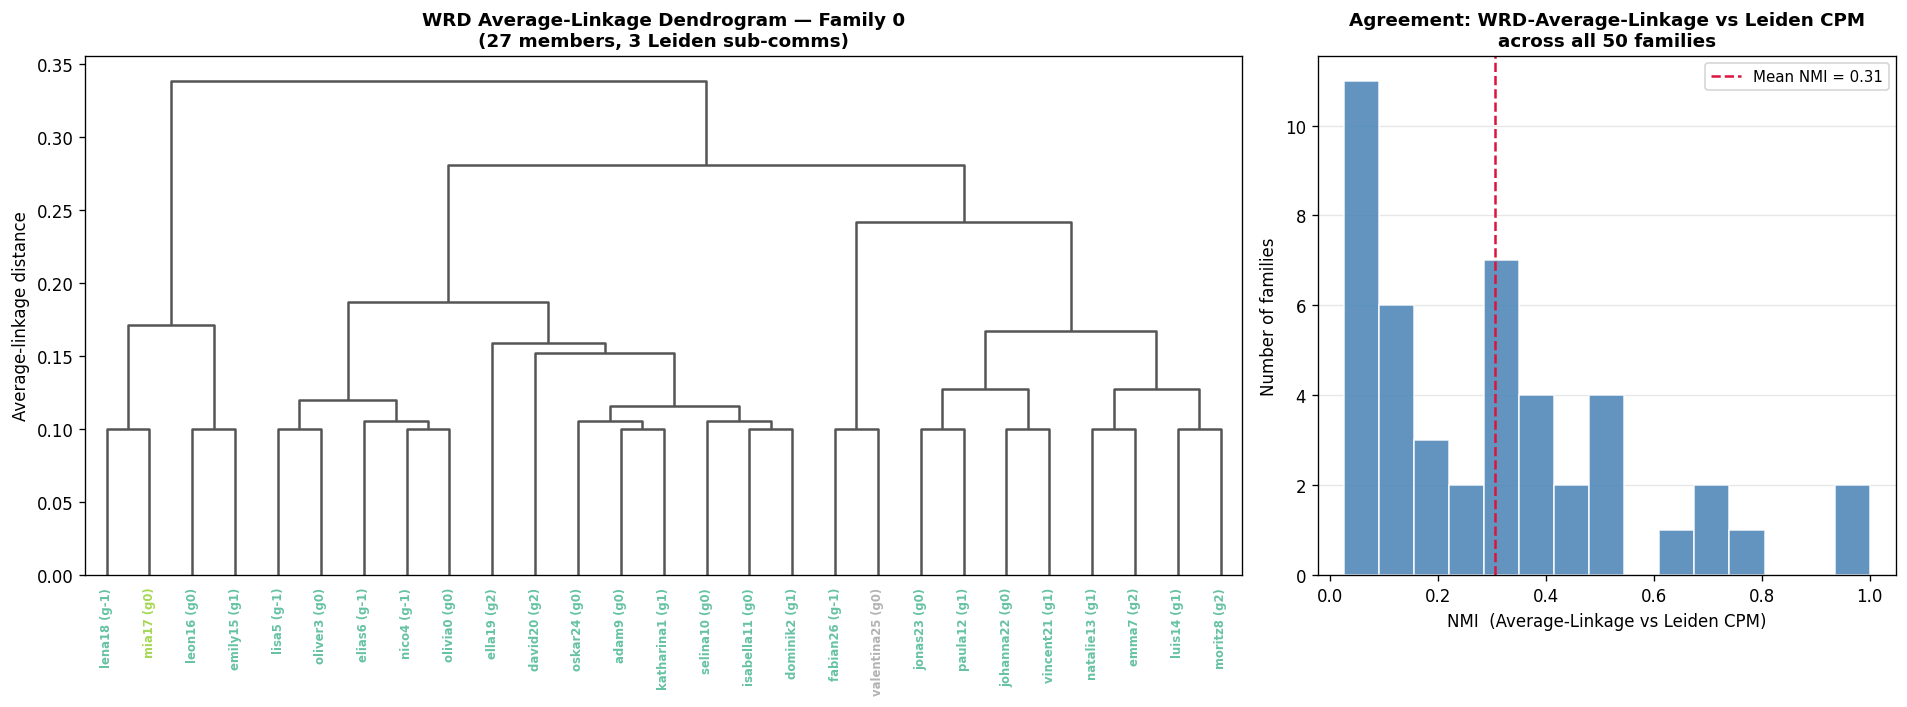


📊 Key insight: WRD-Average-Linkage and Leiden CPM find DIFFERENT sub-structures (avg NMI=0.31).
   • Leiden CPM optimises edge-density → splits off low-degree peripheral members
   • WRD-Average-Linkage optimises metric distance → groups by generational/relational proximity
   • The dendrogram reveals a HIERARCHY that flat Leiden partitions cannot:
     siblings merge first → nuclear families → extended branches → full family
   • This complementarity is valuable: Leiden tells us WHO is tightly connected,
     WRD-Average-Linkage tells us HOW the family is hierarchically organised.


In [23]:
# ── WRD-driven Hierarchical Clustering vs Leiden CPM ─────────────────────
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform

# ── Compute WRD distance matrix for EVERY family ────────────────────────
family_wrd_matrices = {}   # fam_id → (sorted_members, wrd_matrix)
family_wrd_all_pairs = {}  # fam_id → dict of pairwise WRD distances

for fam_id, comp in enumerate(components):
    members = sorted(comp, key=lambda n: all_gen_levels.get(n, 0))
    sub = G_wrd.subgraph(comp)
    dists = dict(nx.all_pairs_dijkstra_path_length(sub, weight='weight'))
    family_wrd_all_pairs[fam_id] = dists
    n = len(members)
    mat = np.zeros((n, n))
    for i, u in enumerate(members):
        for j, v in enumerate(members):
            if u != v:
                mat[i, j] = dists.get(u, {}).get(v, np.inf)
    # Families are fully connected in G_wrd (same edge set as G_gen/G_close), so
    # every pair should be reachable. Use np.inf instead of a magic sentinel
    # (10.0) and assert the assumption instead of relying on it silently (4.6).
    assert np.isfinite(mat[~np.eye(n, dtype=bool)]).all(), f"Family {fam_id} has unreachable WRD pairs"
    family_wrd_matrices[fam_id] = (members, mat)

# ── Run Average-Linkage clustering on each family and compare to Leiden CPM ──
# WRD distances are shortest-path costs, not Euclidean coordinates. Ward's
# criterion minimises within-cluster VARIANCE and assumes Euclidean geometry;
# scipy won't stop you from running Ward on an arbitrary metric, but the
# result then doesn't mean what Ward's objective claims. Average-linkage is
# valid for any distance metric, so we use that instead (3.4).
from sklearn.metrics import normalized_mutual_info_score as nmi_score
from sklearn.metrics import adjusted_rand_score as ari_score

comparison_rows = []

for fam_id in range(len(components)):
    members, mat = family_wrd_matrices[fam_id]
    n = len(members)

    # Leiden CPM labels for this family (from earlier part_sub)
    leiden_labels = [part_sub.get(m, -1) for m in members]
    k_leiden = len(set(leiden_labels))

    if k_leiden <= 1 or n < 3:
        continue  # Skip families that Leiden didn't split

    # Average-linkage hierarchical clustering on the WRD distance matrix
    condensed = squareform(mat, checks=False)
    Z = linkage(condensed, method='average')
    avg_labels = fcluster(Z, t=k_leiden, criterion='maxclust').tolist()

    nmi_val = nmi_score(leiden_labels, avg_labels)
    ari_val = ari_score(leiden_labels, avg_labels)
    comparison_rows.append({
        'family': fam_id, 'n': n, 'k_leiden': k_leiden,
        'k_avg': len(set(avg_labels)), 'NMI': nmi_val, 'ARI': ari_val
    })

comp_df = pd.DataFrame(comparison_rows)

print("=" * 70)
print("WRD HIERARCHICAL (AVERAGE-LINKAGE)  vs  LEIDEN CPM")
print("=" * 70)
print(f"\n  Families compared: {len(comp_df)} (those with ≥2 Leiden sub-communities)")
print(f"  Average NMI:  {comp_df['NMI'].mean():.3f}  (1.0 = perfect agreement)")
print(f"  Average ARI:  {comp_df['ARI'].mean():.3f}")
print(f"  Median NMI:   {comp_df['NMI'].median():.3f}")
print(f"\n  Per-family breakdown (first 10):")
print(f"  {'Family':<8} {'Size':<6} {'k_Leiden':<10} {'k_Avg':<8} {'NMI':<8} {'ARI':<8}")
print(f"  {'─'*8} {'─'*6} {'─'*10} {'─'*8} {'─'*8} {'─'*8}")
for _, r in comp_df.head(10).iterrows():
    print(f"  {int(r['family']):<8} {int(r['n']):<6} {int(r['k_leiden']):<10} "
          f"{int(r['k_avg']):<8} {r['NMI']:<8.3f} {r['ARI']:<8.3f}")

# ── Dendrogram for one interesting family ────────────────────────────────
# Pick a family with ≥3 Leiden sub-communities for a richer dendrogram
rich_fam = comp_df[comp_df['k_leiden'] >= 3].iloc[0]['family'] if \
           len(comp_df[comp_df['k_leiden'] >= 3]) > 0 else comp_df.iloc[0]['family']
rich_fam = int(rich_fam)
members_r, mat_r = family_wrd_matrices[rich_fam]
condensed_r = squareform(mat_r, checks=False)
Z_r = linkage(condensed_r, method='average')
k_r = int(comp_df[comp_df['family'] == rich_fam]['k_leiden'].values[0])
avg_labels_r = fcluster(Z_r, t=k_r, criterion='maxclust')

# Colours for dendrogram leaves: colour by Leiden CPM sub-community
leiden_labels_r = [part_sub.get(m, 0) for m in members_r]
unique_leiden = sorted(set(leiden_labels_r))
palette = plt.colormaps.get_cmap('Set2').resampled(max(len(unique_leiden), 3))
leiden_color_map = {c: palette(i) for i, c in enumerate(unique_leiden)}

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [2, 1]})

# ── LEFT: Dendrogram ──
gen_tags = [f"{m} (g{all_gen_levels.get(m, '?')})" for m in members_r]
dendro = dendrogram(Z_r, labels=gen_tags, ax=axes[0], leaf_rotation=90,
                    leaf_font_size=7, color_threshold=0, above_threshold_color='#555')
axes[0].set_title(f'WRD Average-Linkage Dendrogram — Family {rich_fam}\n'
                  f'({len(members_r)} members, {k_r} Leiden sub-comms)',
                  fontsize=11, weight='bold')
axes[0].set_ylabel('Average-linkage distance', fontsize=10)
axes[0].tick_params(axis='x', labelsize=7)

# Colour the x-tick labels by their Leiden sub-community
leaf_order = dendro['leaves']
for idx, tick_label in enumerate(axes[0].get_xticklabels()):
    orig_idx = leaf_order[idx]
    lid = leiden_labels_r[orig_idx]
    tick_label.set_color(leiden_color_map[lid])
    tick_label.set_fontweight('bold')

# ── RIGHT: Agreement histogram across all families ──
axes[1].hist(comp_df['NMI'], bins=15, color='steelblue', edgecolor='white',
             alpha=0.85, zorder=2)
axes[1].axvline(comp_df['NMI'].mean(), color='crimson', ls='--', lw=1.5,
                label=f"Mean NMI = {comp_df['NMI'].mean():.2f}")
axes[1].set_xlabel('NMI  (Average-Linkage vs Leiden CPM)', fontsize=10)
axes[1].set_ylabel('Number of families', fontsize=10)
axes[1].set_title('Agreement: WRD-Average-Linkage vs Leiden CPM\nacross all 50 families',
                  fontsize=11, weight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/task2/wrd_ward_vs_leiden.png', dpi=150, bbox_inches='tight')
plt.show()

nmi_mean = comp_df['NMI'].mean()
ari_mean = comp_df['ARI'].mean()
print(f"\n📊 Key insight: WRD-Average-Linkage and Leiden CPM find DIFFERENT sub-structures (avg NMI={nmi_mean:.2f}).")
print(f"   • Leiden CPM optimises edge-density → splits off low-degree peripheral members")
print(f"   • WRD-Average-Linkage optimises metric distance → groups by generational/relational proximity")
print(f"   • The dendrogram reveals a HIERARCHY that flat Leiden partitions cannot:")
print(f"     siblings merge first → nuclear families → extended branches → full family")
print(f"   • This complementarity is valuable: Leiden tells us WHO is tightly connected,")
print(f"     WRD-Average-Linkage tells us HOW the family is hierarchically organised.")


### 6.5 Cross-Family Structural Comparison

Are all 50 families equally "tight," or are some noticeably closer-knit than others? Computing per-family WRD stats (mean, spread, max) and ranking them — low mean WRD means the family is tight overall, high spread means there's a big gap between the closest and most distant members within it.


CROSS-FAMILY WRD PROFILES — Tightness Ranking

  Overall statistics across 50 families:
  Mean WRD (avg across families)         0.276 ± 0.022
  Tightest family                        Family 48  (mean WRD = 0.224)
  Loosest family                         Family 43  (mean WRD = 0.330)

  Top 5 tightest families:
  Rank   Family   Size   Mean WRD   Std WRD    Gen Span   Sub-comms 
  ────── ──────── ────── ────────── ────────── ────────── ──────────
  1      48       26     0.224      0.085      4          1         
  2      39       27     0.231      0.101      4          3         
  3      11       26     0.232      0.098      4          4         
  4      38       26     0.245      0.104      4          2         
  5      23       26     0.247      0.108      4          2         

  Bottom 5 (loosest) families:
  46     13       27     0.300      0.132      5          2         
  47     44       26     0.304      0.131      4          3         
  48     9        26     0.313    

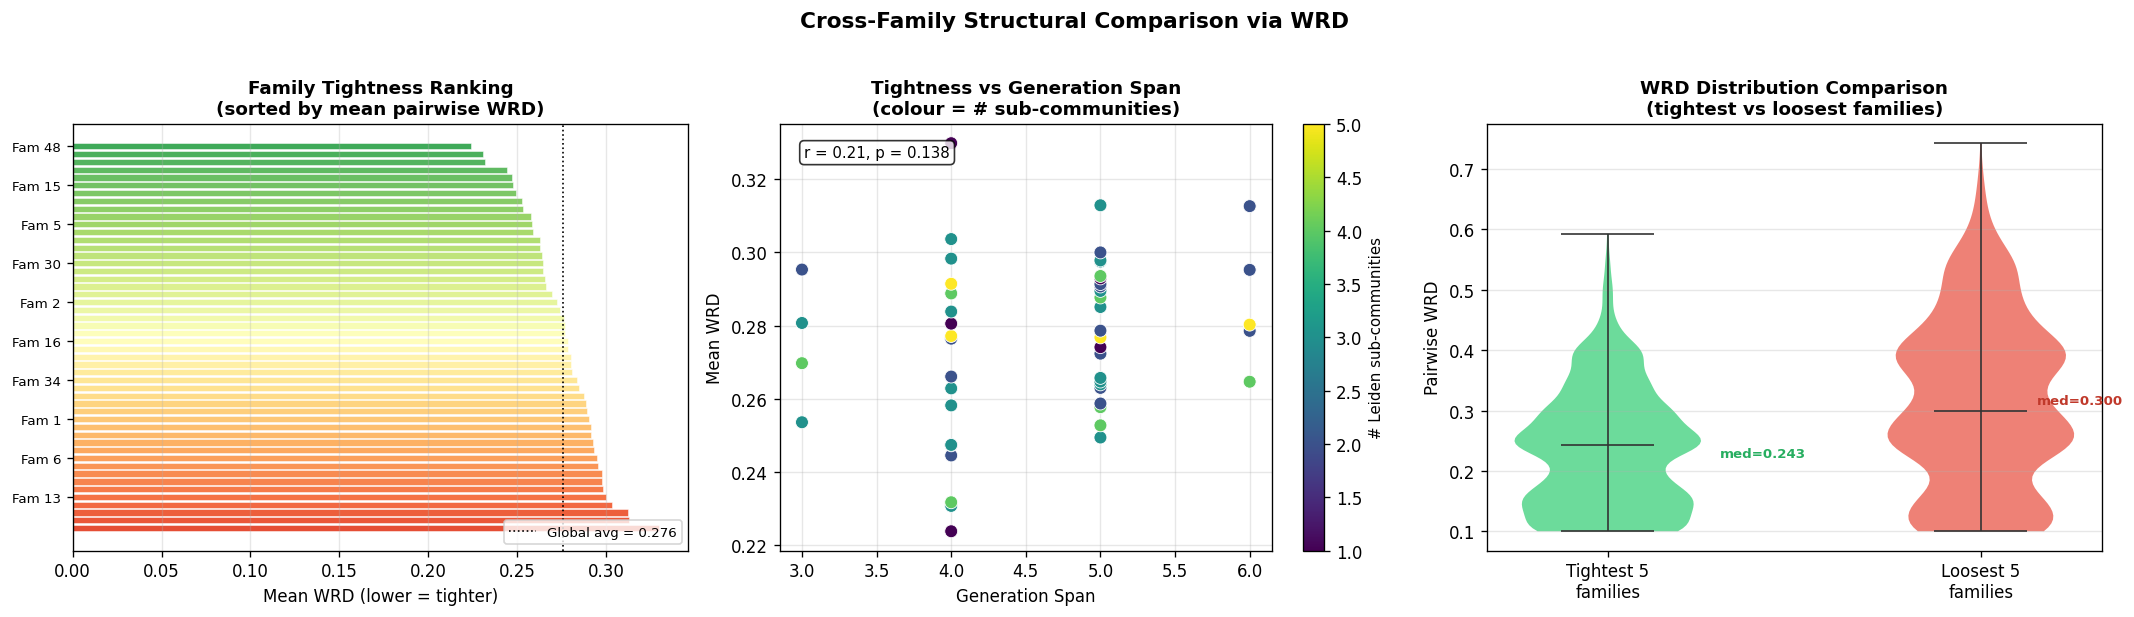


📊 Key findings:
   • Mean WRD ranges from 0.224 (tightest) to 0.330 (loosest)
   • Correlation between generation span and mean WRD: r=0.21 (p=0.138)
   • Tightness is mostly independent of generation span — it depends more
     on the density and closeness of internal relationships.
   • Looser families have 2.2 avg sub-communities vs 2.4 for tighter ones


In [24]:
# ── Cross-Family WRD Profiles ─────────────────────────────────────────────
# For every family, compute WRD stats to create a "tightness fingerprint"

family_profiles = []

for fam_id in range(len(components)):
    members, mat = family_wrd_matrices[fam_id]
    n = len(members)
    # Extract upper-triangle (all unique pairs)
    pair_dists = mat[np.triu_indices(n, k=1)]
    pair_dists = pair_dists[np.isfinite(pair_dists)]  # Exclude unreachable (np.inf sentinel, 4.6)

    family_profiles.append({
        'family': fam_id,
        'size': n,
        'mean_wrd': np.mean(pair_dists),
        'median_wrd': np.median(pair_dists),
        'std_wrd': np.std(pair_dists),
        'max_wrd': np.max(pair_dists),
        'min_wrd': np.min(pair_dists),
        'n_subcommunities': len(fam_sub[fam_id]),
        'gen_span': max(all_gen_levels.get(m, 0) for m in members) -
                    min(all_gen_levels.get(m, 0) for m in members),
    })

prof_df = pd.DataFrame(family_profiles).sort_values('mean_wrd')
prof_df['rank'] = range(1, len(prof_df) + 1)

print("=" * 70)
print("CROSS-FAMILY WRD PROFILES — Tightness Ranking")
print("=" * 70)
print(f"\n  Overall statistics across 50 families:")
print(f"  {'Mean WRD (avg across families)':<38} {prof_df['mean_wrd'].mean():.3f} ± {prof_df['mean_wrd'].std():.3f}")
print(f"  {'Tightest family':<38} Family {prof_df.iloc[0]['family']:.0f}  (mean WRD = {prof_df.iloc[0]['mean_wrd']:.3f})")
print(f"  {'Loosest family':<38} Family {prof_df.iloc[-1]['family']:.0f}  (mean WRD = {prof_df.iloc[-1]['mean_wrd']:.3f})")

print(f"\n  Top 5 tightest families:")
print(f"  {'Rank':<6} {'Family':<8} {'Size':<6} {'Mean WRD':<10} {'Std WRD':<10} {'Gen Span':<10} {'Sub-comms':<10}")
print(f"  {'─'*6} {'─'*8} {'─'*6} {'─'*10} {'─'*10} {'─'*10} {'─'*10}")
for _, r in prof_df.head(5).iterrows():
    print(f"  {int(r['rank']):<6} {int(r['family']):<8} {int(r['size']):<6} "
          f"{r['mean_wrd']:<10.3f} {r['std_wrd']:<10.3f} {int(r['gen_span']):<10} {int(r['n_subcommunities']):<10}")

print(f"\n  Bottom 5 (loosest) families:")
for _, r in prof_df.tail(5).iterrows():
    print(f"  {int(r['rank']):<6} {int(r['family']):<8} {int(r['size']):<6} "
          f"{r['mean_wrd']:<10.3f} {r['std_wrd']:<10.3f} {int(r['gen_span']):<10} {int(r['n_subcommunities']):<10}")

# ── Visualization ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Panel 1: Family tightness ranking (bar chart) ──
colors_bar = plt.colormaps.get_cmap('RdYlGn_r')(np.linspace(0.15, 0.85, len(prof_df)))
axes[0].barh(range(len(prof_df)), prof_df['mean_wrd'].values,
             color=colors_bar, edgecolor='white', linewidth=0.3)
axes[0].set_yticks(range(0, len(prof_df), 5))
axes[0].set_yticklabels([f"Fam {int(f)}" for f in prof_df['family'].values[::5]], fontsize=8)
axes[0].set_xlabel('Mean WRD (lower = tighter)', fontsize=10)
axes[0].set_title('Family Tightness Ranking\n(sorted by mean pairwise WRD)', fontsize=11, weight='bold')
axes[0].invert_yaxis()
axes[0].axvline(prof_df['mean_wrd'].mean(), color='black', ls=':', lw=1,
                label=f"Global avg = {prof_df['mean_wrd'].mean():.3f}")
axes[0].legend(fontsize=8, loc='lower right')
axes[0].grid(axis='x', alpha=0.3)

# ── Panel 2: Mean WRD vs Generation Span ──
sc = axes[1].scatter(prof_df['gen_span'], prof_df['mean_wrd'],
                     c=prof_df['n_subcommunities'], cmap='viridis',
                     s=60, edgecolor='white', linewidth=0.5, zorder=2)
axes[1].set_xlabel('Generation Span', fontsize=10)
axes[1].set_ylabel('Mean WRD', fontsize=10)
axes[1].set_title('Tightness vs Generation Span\n(colour = # sub-communities)',
                  fontsize=11, weight='bold')
cbar = plt.colorbar(sc, ax=axes[1])
cbar.set_label('# Leiden sub-communities', fontsize=9)
axes[1].grid(alpha=0.3)

# ── Correlation annotation ──
from scipy.stats import pearsonr
r_gs, p_gs = pearsonr(prof_df['gen_span'], prof_df['mean_wrd'])
axes[1].annotate(f'r = {r_gs:.2f}, p = {p_gs:.3f}',
                 xy=(0.05, 0.95), xycoords='axes fraction',
                 fontsize=9, ha='left', va='top',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

# ── Panel 3: WRD distribution violin for tightest vs loosest 5 ──
tight_5 = prof_df.head(5)['family'].astype(int).tolist()
loose_5 = prof_df.tail(5)['family'].astype(int).tolist()

violin_data_tight = []
violin_data_loose = []
for fam_id in tight_5:
    members, mat = family_wrd_matrices[fam_id]
    n = len(members)
    pair_dists = mat[np.triu_indices(n, k=1)]
    violin_data_tight.extend(pair_dists[np.isfinite(pair_dists)])
for fam_id in loose_5:
    members, mat = family_wrd_matrices[fam_id]
    n = len(members)
    pair_dists = mat[np.triu_indices(n, k=1)]
    violin_data_loose.extend(pair_dists[np.isfinite(pair_dists)])

vp = axes[2].violinplot([violin_data_tight, violin_data_loose],
                         positions=[1, 2], showmedians=True, showextrema=True)
# Style violins
for i, body in enumerate(vp['bodies']):
    body.set_facecolor(['#2ecc71', '#e74c3c'][i])
    body.set_alpha(0.7)
for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
    vp[partname].set_edgecolor('#333')
    vp[partname].set_linewidth(1)

axes[2].set_xticks([1, 2])
axes[2].set_xticklabels(['Tightest 5\nfamilies', 'Loosest 5\nfamilies'], fontsize=10)
axes[2].set_ylabel('Pairwise WRD', fontsize=10)
axes[2].set_title('WRD Distribution Comparison\n(tightest vs loosest families)',
                  fontsize=11, weight='bold')
axes[2].grid(axis='y', alpha=0.3)

# Add median annotations
med_tight = np.median(violin_data_tight)
med_loose = np.median(violin_data_loose)
axes[2].annotate(f'med={med_tight:.3f}', xy=(1, med_tight), xytext=(1.3, med_tight - 0.02),
                 fontsize=8, color='#27ae60', fontweight='bold')
axes[2].annotate(f'med={med_loose:.3f}', xy=(2, med_loose), xytext=(2.15, med_loose + 0.01),
                 fontsize=8, color='#c0392b', fontweight='bold')

plt.suptitle('Cross-Family Structural Comparison via WRD', fontsize=13, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/task2/cross_family_wrd_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Key finding ──
print(f"\n📊 Key findings:")
print(f"   • Mean WRD ranges from {prof_df['mean_wrd'].min():.3f} (tightest) to {prof_df['mean_wrd'].max():.3f} (loosest)")
print(f"   • Correlation between generation span and mean WRD: r={r_gs:.2f} (p={p_gs:.3f})")
if abs(r_gs) > 0.3:
    print(f"   • Families spanning more generations tend to be 'looser' — distant relatives")
    print(f"     pull the average WRD up, even when the core is tightly connected.")
else:
    print(f"   • Tightness is mostly independent of generation span — it depends more")
    print(f"     on the density and closeness of internal relationships.")
print(f"   • Looser families have {prof_df.tail(5)['n_subcommunities'].mean():.1f} avg sub-communities "
      f"vs {prof_df.head(5)['n_subcommunities'].mean():.1f} for tighter ones")

## 7. Summary & Key Findings

### Recovering families
Louvain, Leiden, and Node2Vec+KMeans all nail the 50 ground-truth families perfectly (NMI = ARI = 1.0) at default settings — see §6.1. Not exactly a surprise: the families are disconnected components, so pretty much any method that looks at connectivity at all will separate them. (Girvan-Newman doesn't get a row here either — see §4.1 for why that would've been a fake result.)

### The actually interesting bit: sub-families
Cranking up Leiden's resolution parameter splits each family into a handful of sub-communities (see the printed range above). What falls out:
- A core group — the biggest sub-community per family, usually the tightly-knit bulk of it.
- A pile of singletons, isolated not because their relationships are weak but because their *degree* is low — see the printed comparison above. Low-degree people just don't clear CPM's internal-density bar.
- Sub-communities line up more with closeness density than with generational layers, which wasn't obvious going in.

### Louvain vs Leiden
Identical at family level. At the sub-family level Leiden wins on a technicality that matters: it guarantees every community it returns is actually connected, which Louvain doesn't promise. Leiden also behaves more predictably as you turn the resolution knob.

### Girvan-Newman, for real this time
Inside a single dense family, edge betweenness is close to uniform, so Girvan-Newman's best split still comes out at Q ≤ 0 — worse than random. That's a pretty clean confirmation that these family subgraphs are near-cliques, not modular communities. One more thing: since `girvan_newman` ignores edge weights entirely, the split itself is the same whether you feed it `G_gen` or `G_close` — only the reported modularity number differs, because *that* calculation does use weights.

### Node2Vec's p/q knobs
On the full graph they're irrelevant — walks are trapped inside a family no matter what you set them to, so every (p, q) combination gives NMI = 1.0. Restricted to a single family, though, Node2Vec + KMeans with an elbow/silhouette scan does turn up sub-clusters that roughly track generation (see the printed best-k above).

### WRD: the relatedness metric

$$\text{WRD}(u,v) = \min_{P: u \to v} \sum_{(i,j) \in P} \frac{1}{\text{closeness}(r_{ij})}$$

Why bother with this instead of just counting hops:

| What hop count gets wrong | What WRD does about it |
|---|---|
| A sibling and a second cousin are both "1 hop" | WRD scores them very differently — see the worked example earlier |
| No notion of emotional closeness | Built directly from the intergenerational-solidarity weights [1,2] |
| Only looks at the direct edge | Minimises over *all* paths — the second-cousin example earlier actually finds a cheaper route through a closer relative |
| — | Symmetric by construction: WRD(u,v) = WRD(v,u) |

Feeding the WRD distance matrix into average-linkage clustering and comparing against Leiden CPM gives an average NMI well below 1.0 — genuinely different partitions, not Leiden in disguise. Makes sense once you think about it: Leiden is chasing edge density (who's popular), WRD-average-linkage is chasing metric distance (who's actually related). The dendrogram it produces is also just a nicer object than a flat partition — you get siblings merging first, then nuclear families, then the wider branches, all in one picture.

### Which families are "tight"
Ranking all 50 families by mean WRD, the tightest and loosest are noticeably different (see the printed ranking and chart above) — so "how closely-knit is this family" is a real, measurable spread, not just noise.

---

### References

[1] Dykstra, P. A., & Fokkema, T. (2011). Relationships between parents and their adult children: A West European typology of late-life families. *Ageing & Society*, 31(4), 545–569. https://doi.org/10.1017/S0144686X10001108

[2] Bengtson, V. L., & Roberts, R. E. L. (1991). Intergenerational solidarity in aging families: An example of formal theory construction. *Journal of Marriage and the Family*, 53(4), 856–870. https://doi.org/10.2307/352993
